# Import Libraries

In [ ]:
! pip install seaborn
! pip install lightgbm
! pip install kagglehub

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
import calendar
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LayerNormalization, MultiHeadAttention, Add, Concatenate, Dropout, Reshape, Conv2D, BatchNormalization, ReLU, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, AveragePooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub
from tensorflow.keras import layers

# Downloading Dataset

In [ ]:
data=kagglehub.dataset_download("fedesoriano/wind-speed-prediction-dataset")
print("Path to dataset files:", data)

100%|██████████| 71.6k/71.6k [00:00<00:00, 668kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1


In [ ]:
import os

dataset_path = '/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1'
files = os.listdir(dataset_path)
print(files)

['wind_dataset.csv']


In [ ]:
df=pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1/wind_dataset.csv')

# Explorotory Data Analysis（EDA）

## Attribute Information
DATE (YYYY-MM-DD)

WIND: Average wind speed [knots]

IND: First indicator value

RAIN: Precipitation Amount (mm)

IND.1: Second indicator value

T.MAX: Maximum Temperature (°C)

IND.2: Third indicator value

T.MIN: Minimum Temperature (°C)

T.MIN.G: 09utc Grass Minimum Temperature (°C)

In [ ]:
df.head(5)

,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
0,1961-01-01,13.67,0,0.2,0.0,9.5,0.0,3.7,-1.0
1,1961-01-02,11.50,0,5.1,0.0,7.2,0.0,4.2,1.1
2,1961-01-03,11.25,0,0.4,0.0,5.5,0.0,0.5,-0.5
3,1961-01-04,8.63,0,0.2,0.0,5.6,0.0,0.4,-3.2
4,1961-01-05,11.92,0,10.4,0.0,7.2,1.0,-1.5,-7.5


In [ ]:
df.tail(5)

,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
6569,1978-12-27,14.46,0,16.8,0.0,9.8,0.0,4.0,0.0
6570,1978-12-28,14.33,0,16.0,0.0,9.1,0.0,8.5,8.0
6571,1978-12-29,19.17,0,14.7,0.0,5.0,0.0,3.5,3.2
6572,1978-12-30,18.08,0,4.9,0.0,2.9,0.0,0.3,-0.5
6573,1978-12-31,19.25,0,0.5,0.0,1.2,1.0,-1.5,-3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     6574 non-null   object 
 1   WIND     6574 non-null   float64
 2   IND      6574 non-null   int64  
 3   RAIN     6574 non-null   float64
 4   IND.1    6513 non-null   float64
 5   T.MAX    5953 non-null   float64
 6   IND.2    6513 non-null   float64
 7   T.MIN    5900 non-null   float64
 8   T.MIN.G  6214 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 462.4+ KB


In [ ]:
df.isnull().sum()

,0
DATE,0
WIND,0
IND,0
RAIN,0
IND.1,61
T.MAX,621
IND.2,61
T.MIN,674
T.MIN.G,360


In [ ]:
# removing null values
df=df.dropna()

In [ ]:
df.shape

(5638, 9)

In [ ]:
df.columns

Index(['DATE', 'WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN',
       'T.MIN.G'],
      dtype='object')

In [ ]:
(df==0).sum()

,0
DATE,0
WIND,1
IND,5041
RAIN,2462
IND.1,5602
T.MAX,1
IND.2,5127
T.MIN,39
T.MIN.G,87


In [ ]:
df.nunique()

,0
DATE,5638
WIND,569
IND,3
RAIN,219
IND.1,3
T.MAX,245
IND.2,4
T.MIN,246
T.MIN.G,280


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WIND,5638.0,9.682297,4.938009,0.0,5.91,9.08,12.83,30.37
IND,5638.0,0.399610,1.189562,0.0,0.00,0.00,0.00,4.00
RAIN,5638.0,1.875647,3.973763,0.0,0.00,0.20,2.00,67.00
IND.1,5638.0,0.012593,0.157654,0.0,0.00,0.00,0.00,2.00
T.MAX,5638.0,13.285669,4.890483,-0.1,9.60,13.10,17.20,26.80
IND.2,5638.0,0.093828,0.303538,0.0,0.00,0.00,0.00,3.00
T.MIN,5638.0,6.446949,4.626693,-11.5,3.10,6.50,10.00,18.00
T.MIN.G,5638.0,2.757627,5.576713,-13.5,-1.00,3.00,7.00,15.80


In [ ]:
df.columns

Index(['DATE', 'WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN',
       'T.MIN.G'],
      dtype='object')

In [ ]:
# Spiliting time data to year-month-day
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')

df['day'] = df['DATE'].dt.day.astype(int)
df['month'] = df['DATE'].dt.month.astype(int)
df['year'] = df['DATE'].dt.year.astype(int)


print(df.head())

        DATE   WIND  IND  RAIN  IND.1  T.MAX  IND.2  T.MIN  T.MIN.G  day  \
0 1961-01-01  13.67    0   0.2    0.0    9.5    0.0    3.7     -1.0    1   
1 1961-01-02  11.50    0   5.1    0.0    7.2    0.0    4.2      1.1    2   
2 1961-01-03  11.25    0   0.4    0.0    5.5    0.0    0.5     -0.5    3   
3 1961-01-04   8.63    0   0.2    0.0    5.6    0.0    0.4     -3.2    4   
4 1961-01-05  11.92    0  10.4    0.0    7.2    1.0   -1.5     -7.5    5   

   month  year  
0      1  1961  
1      1  1961  
2      1  1961  
3      1  1961  
4      1  1961  


## Visualization

###  Heatmap

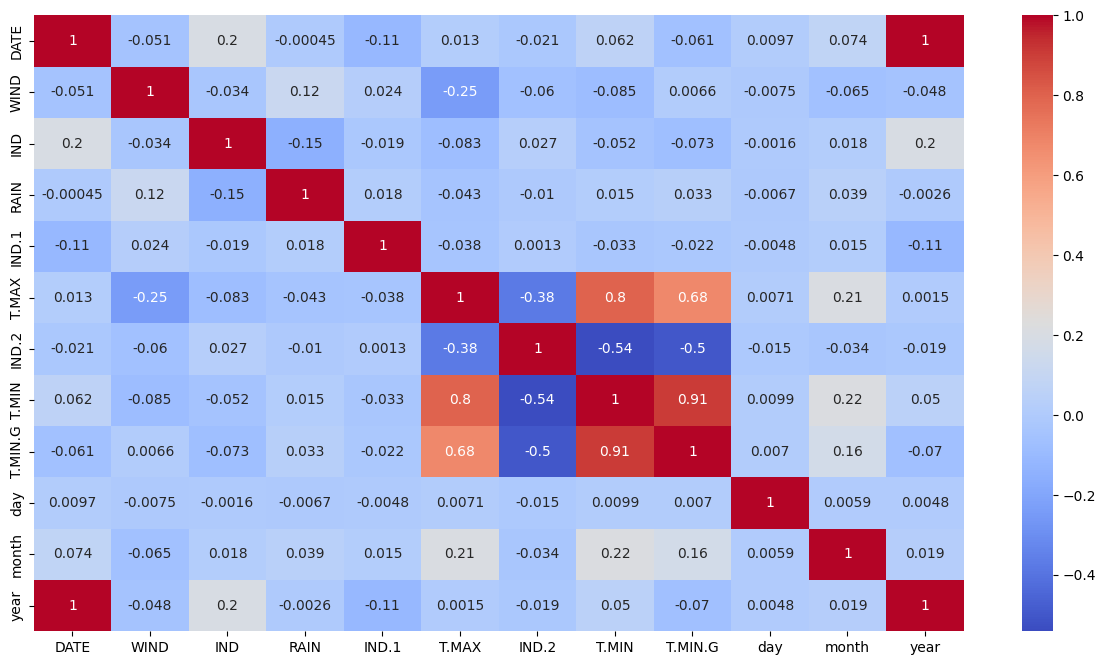

In [ ]:
# Heat map
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True, cbar=True,cmap='coolwarm')
plt.show()

Observation
* there is a strong corrolation between T.Min.G amd T.min

### Pairplot





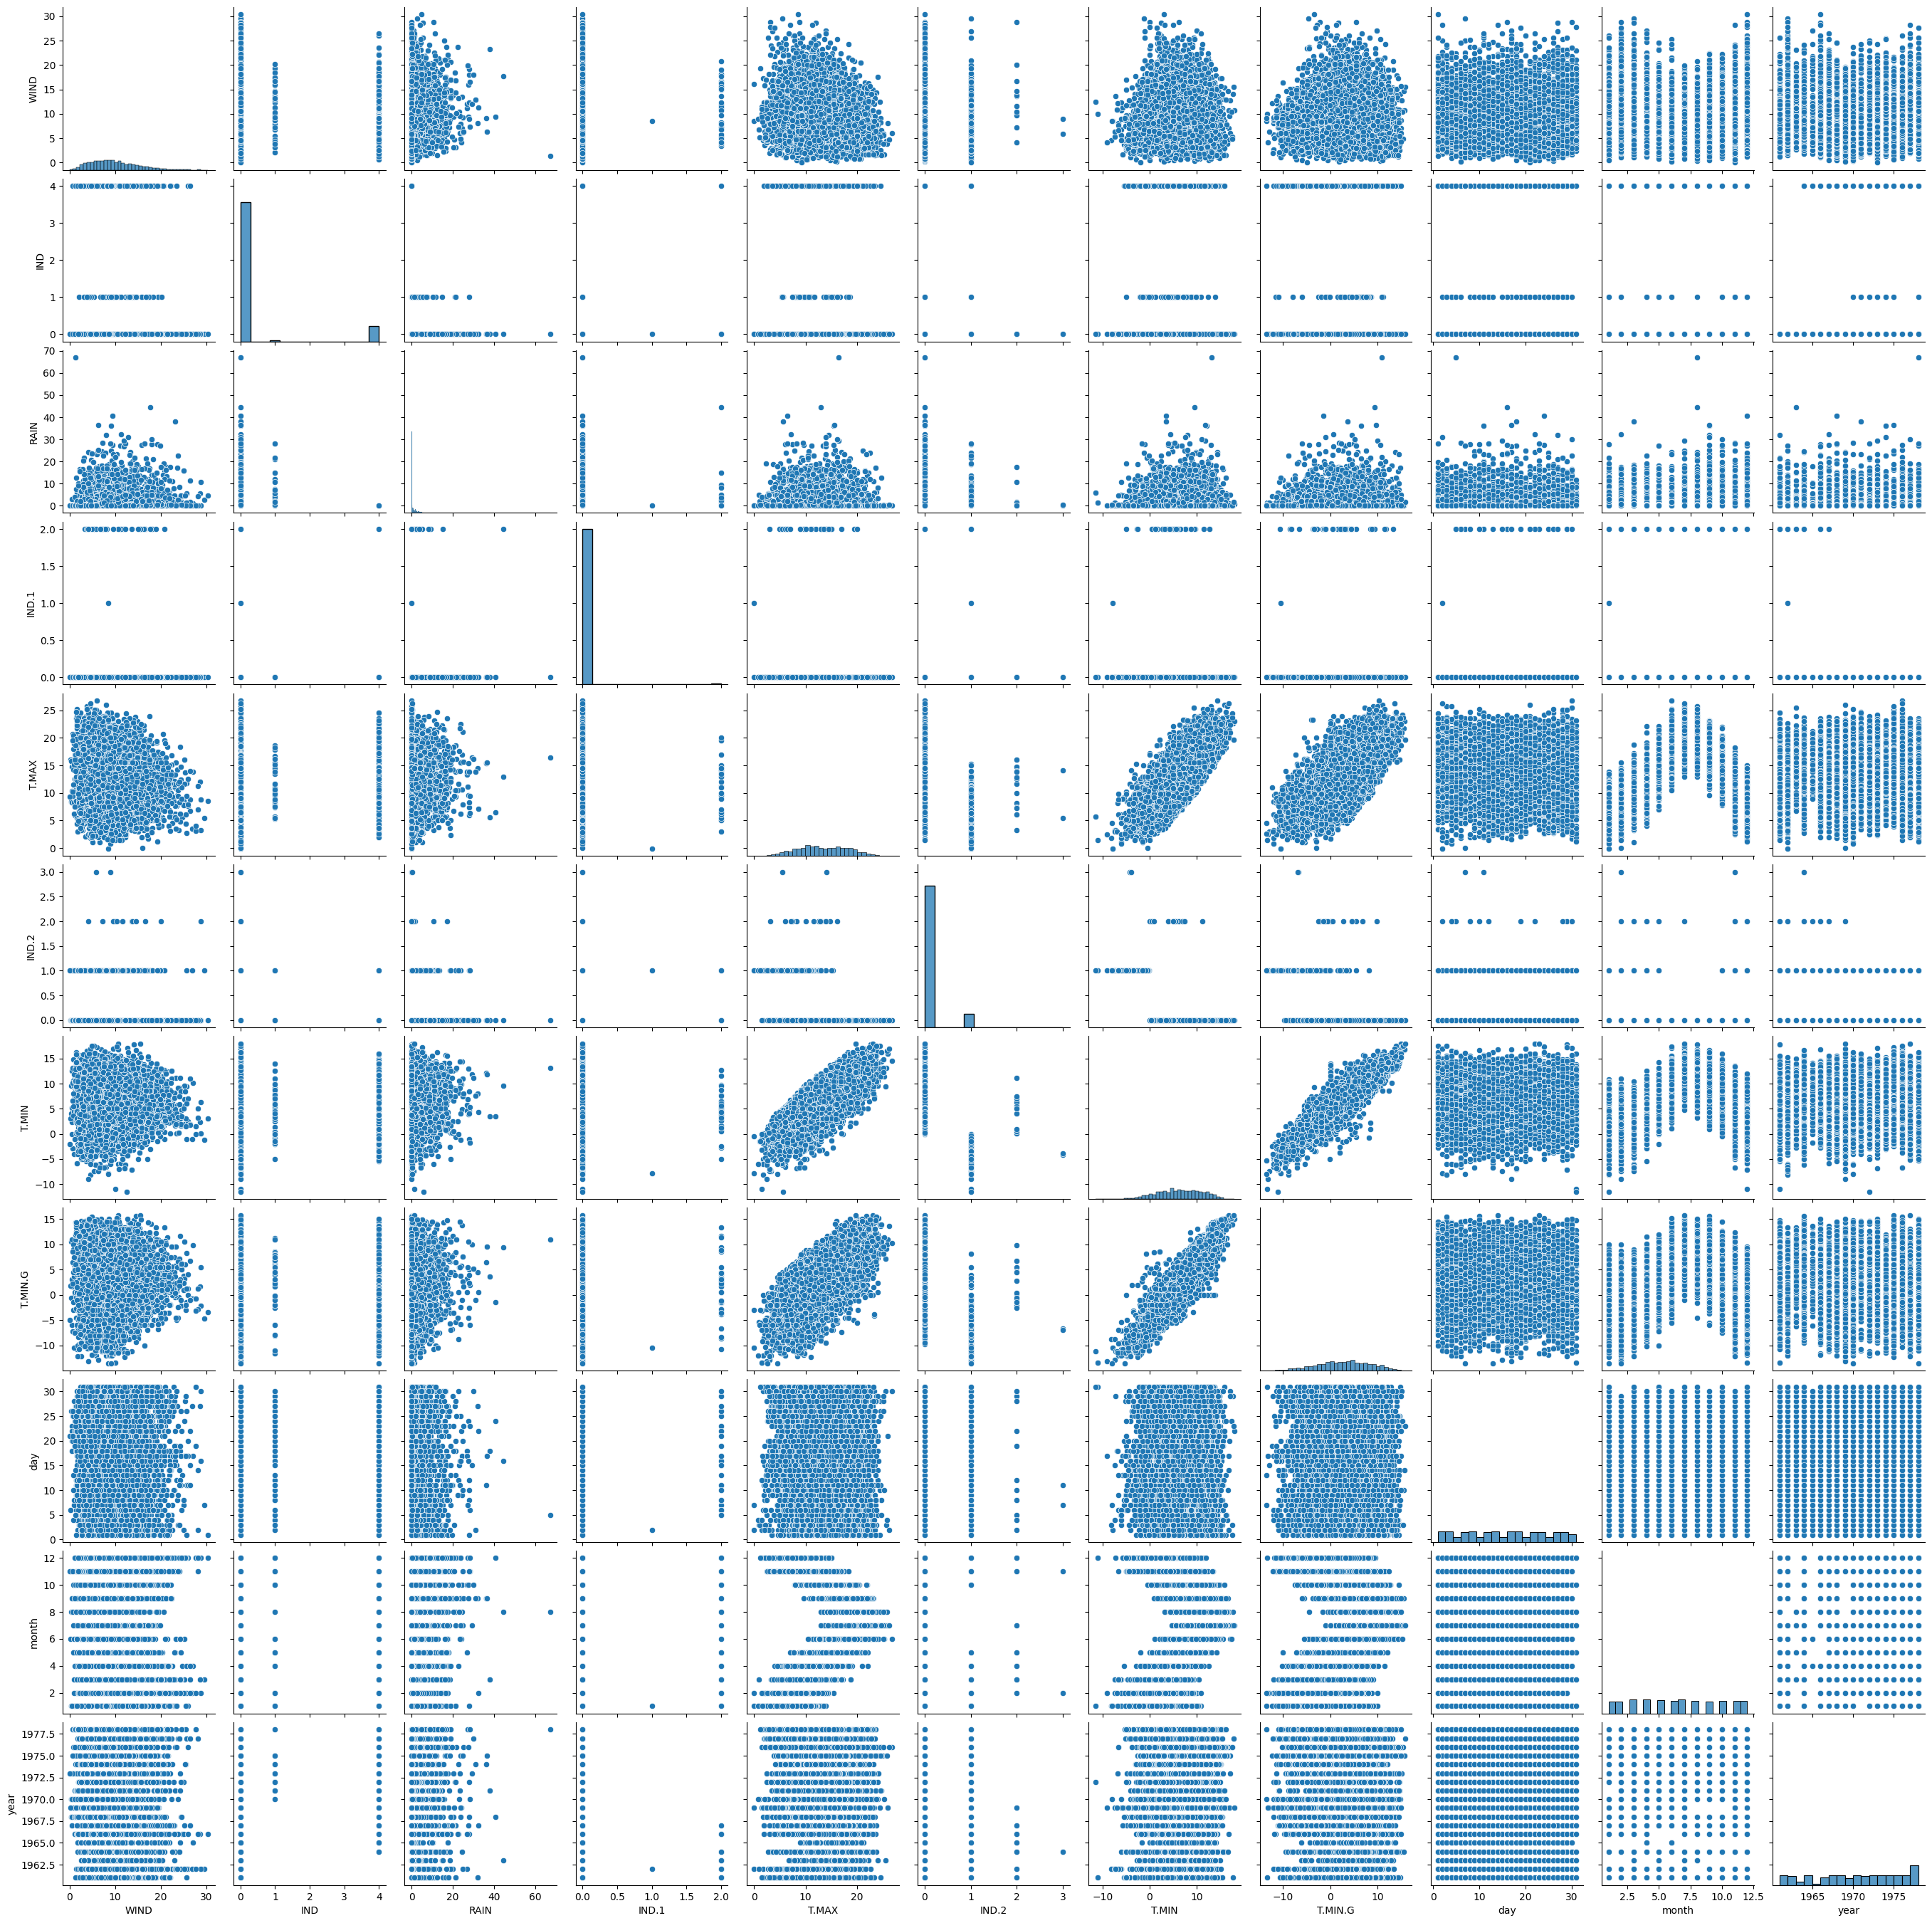

In [ ]:
filterwarnings("ignore", category=FutureWarning)
sns.pairplot(df)

### Outliers Check

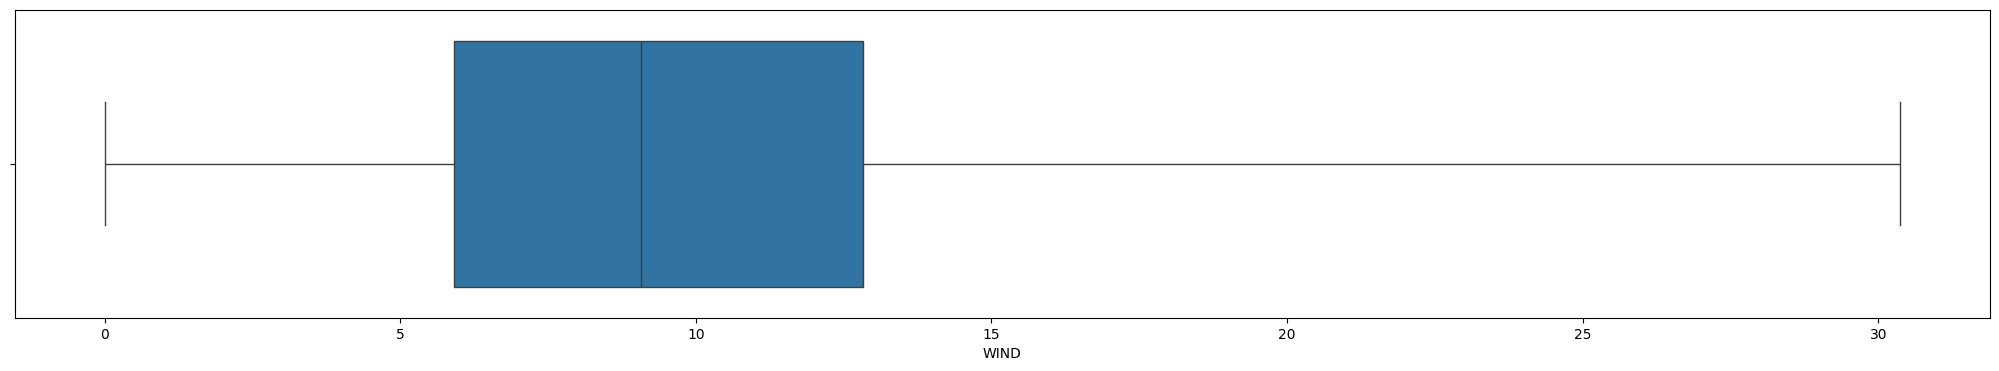

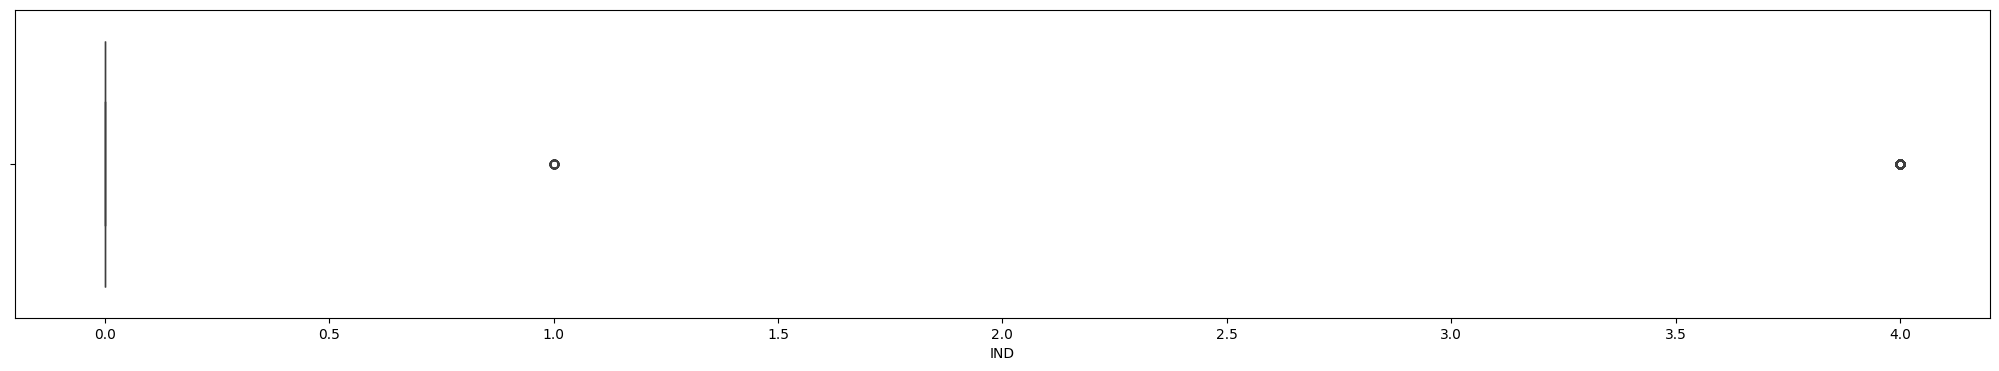

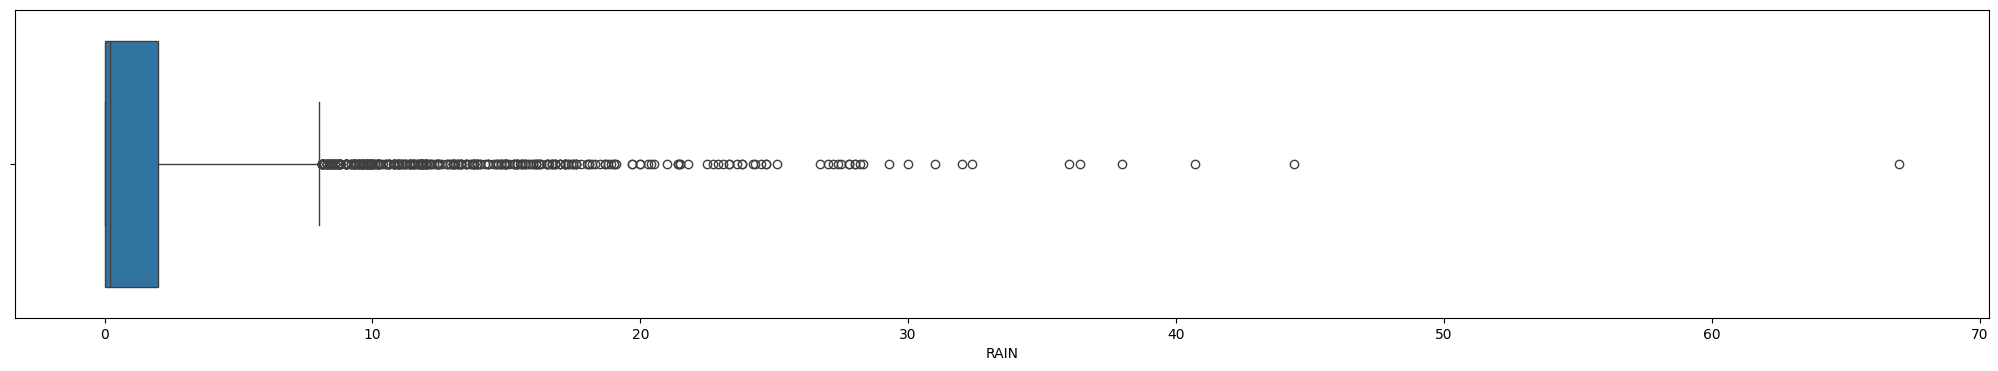

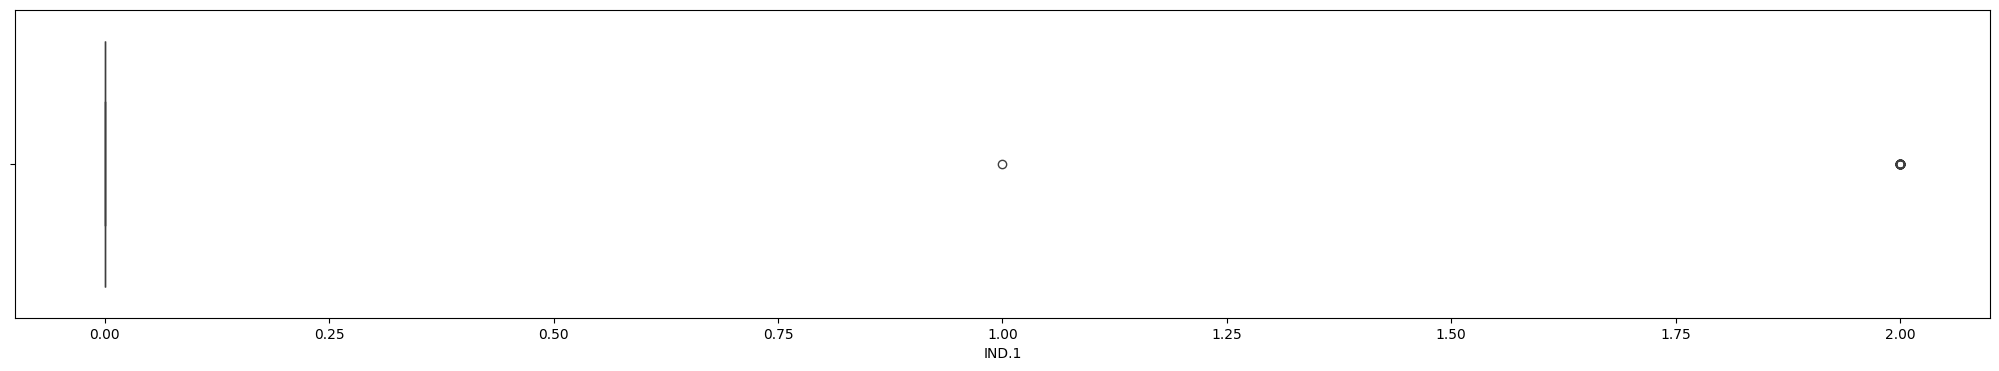

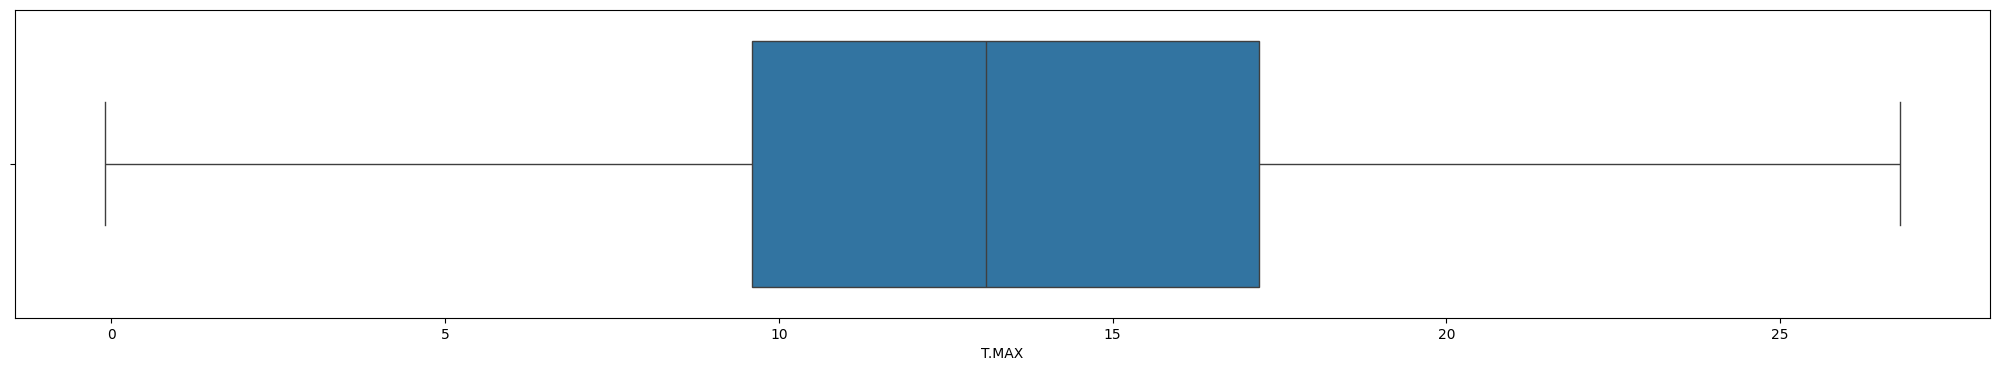

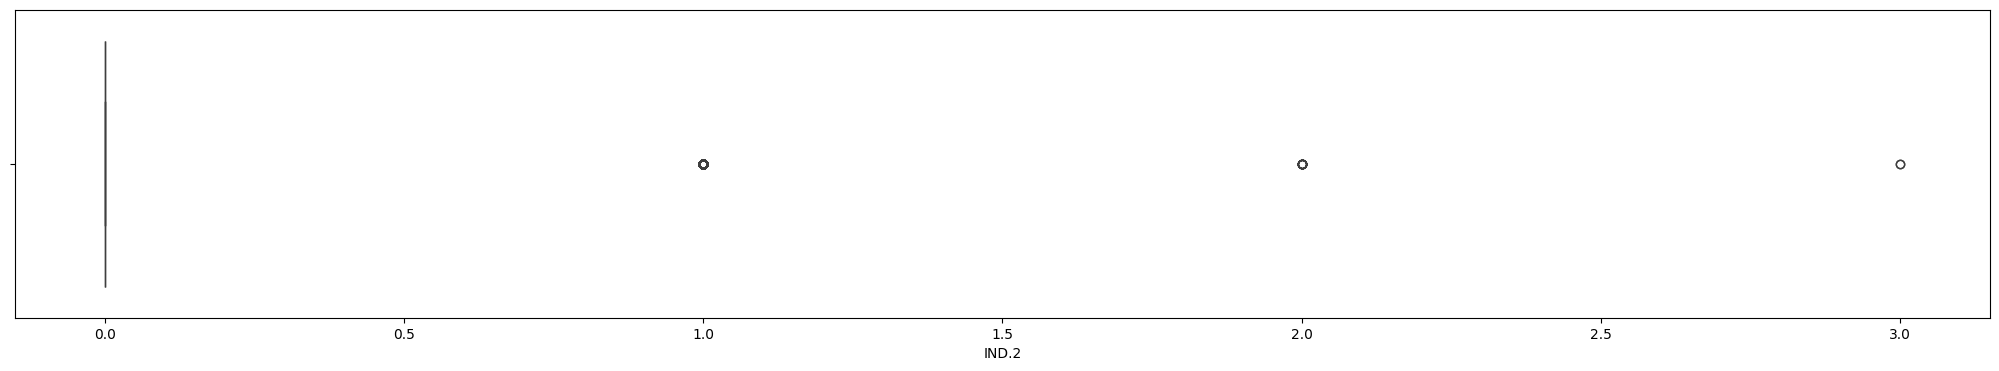

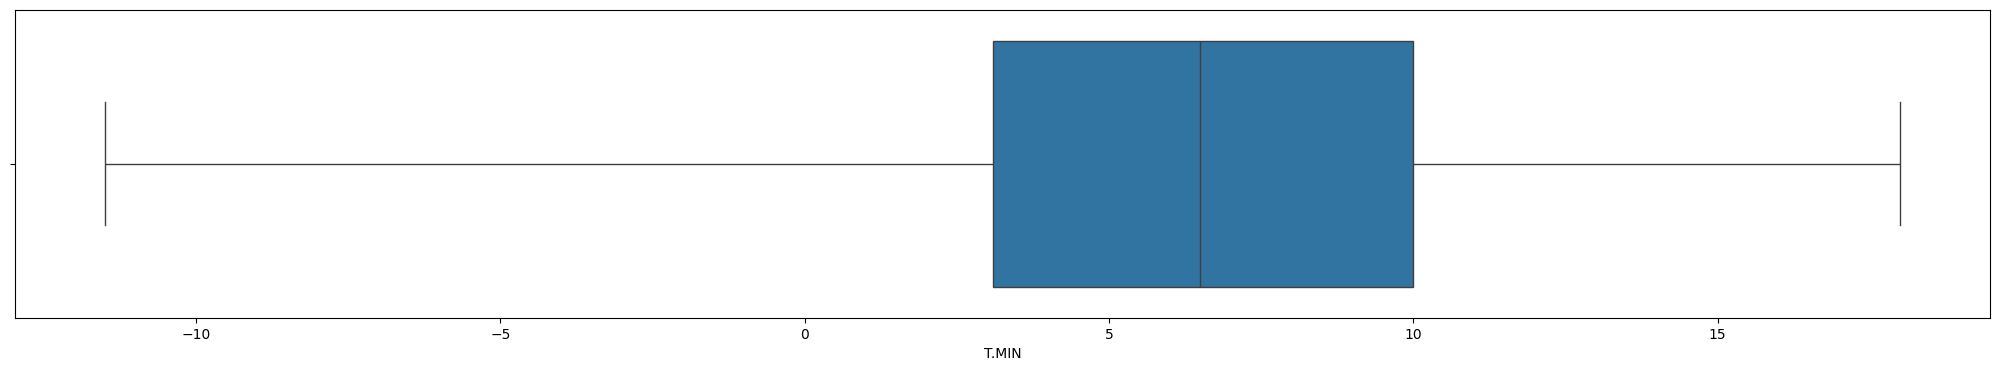

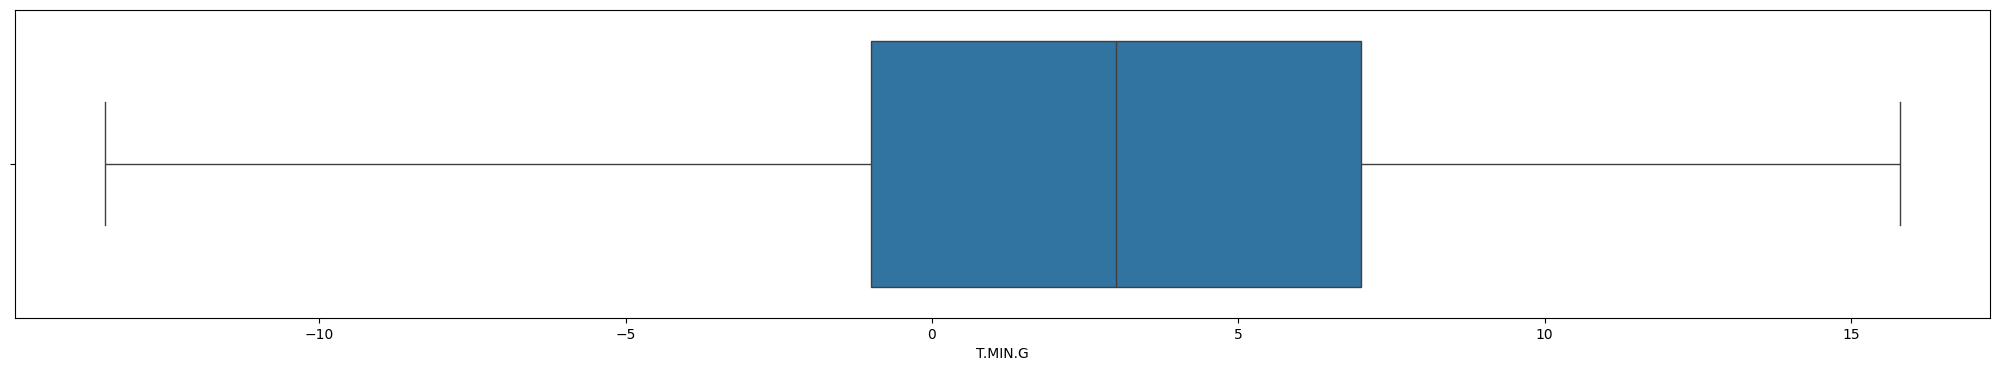

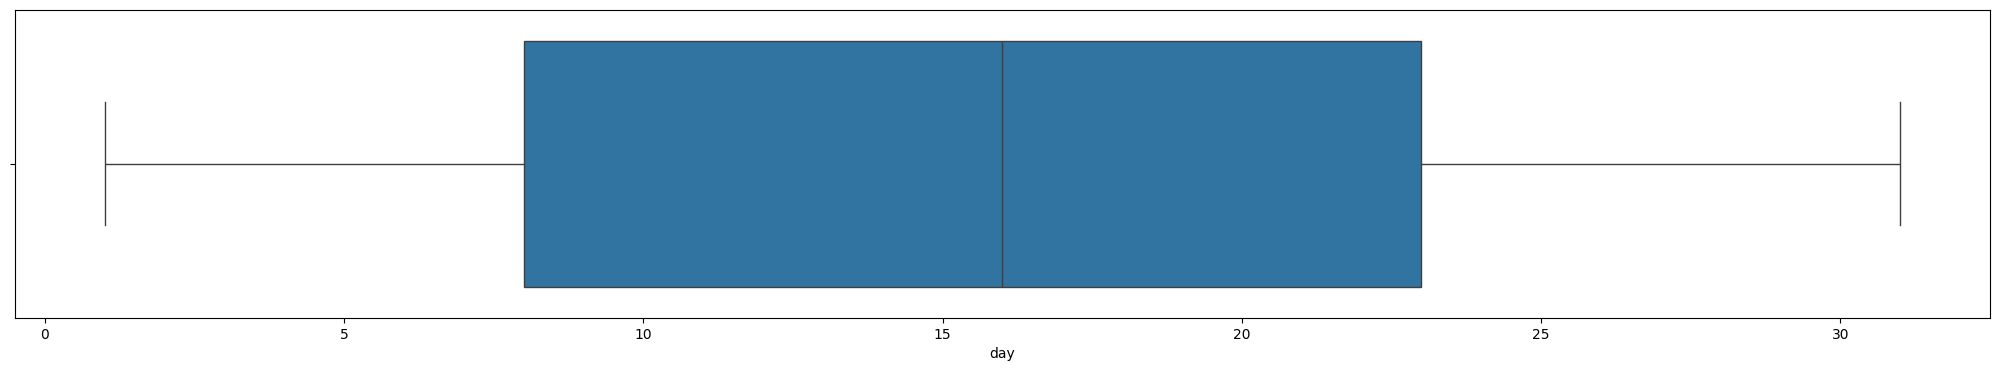

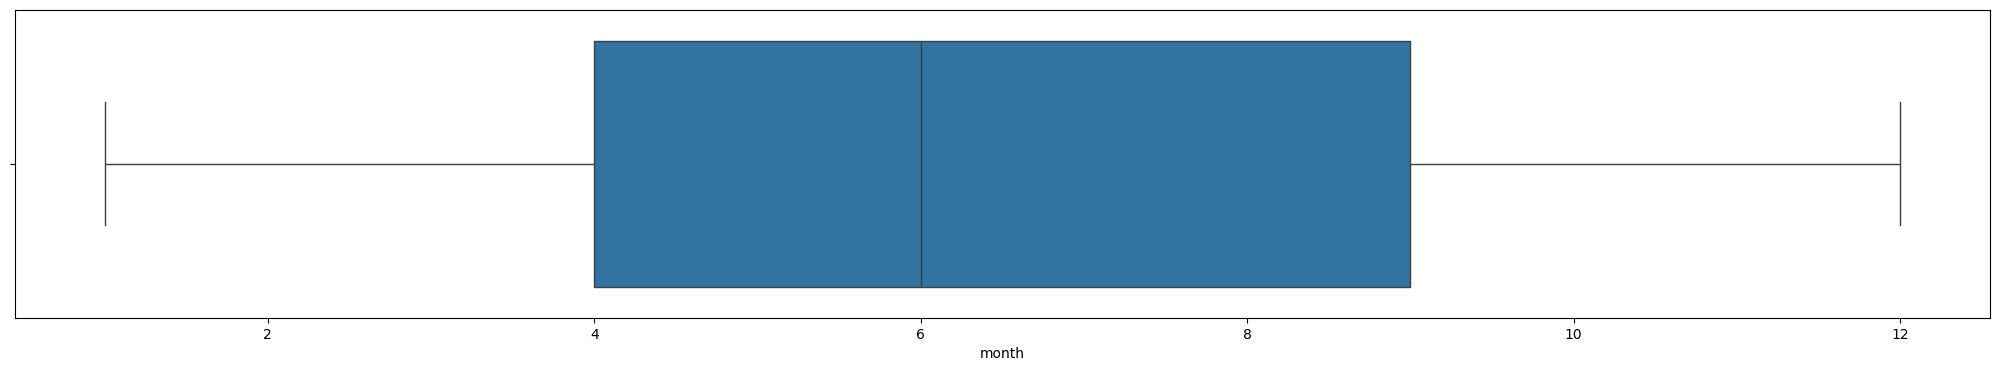

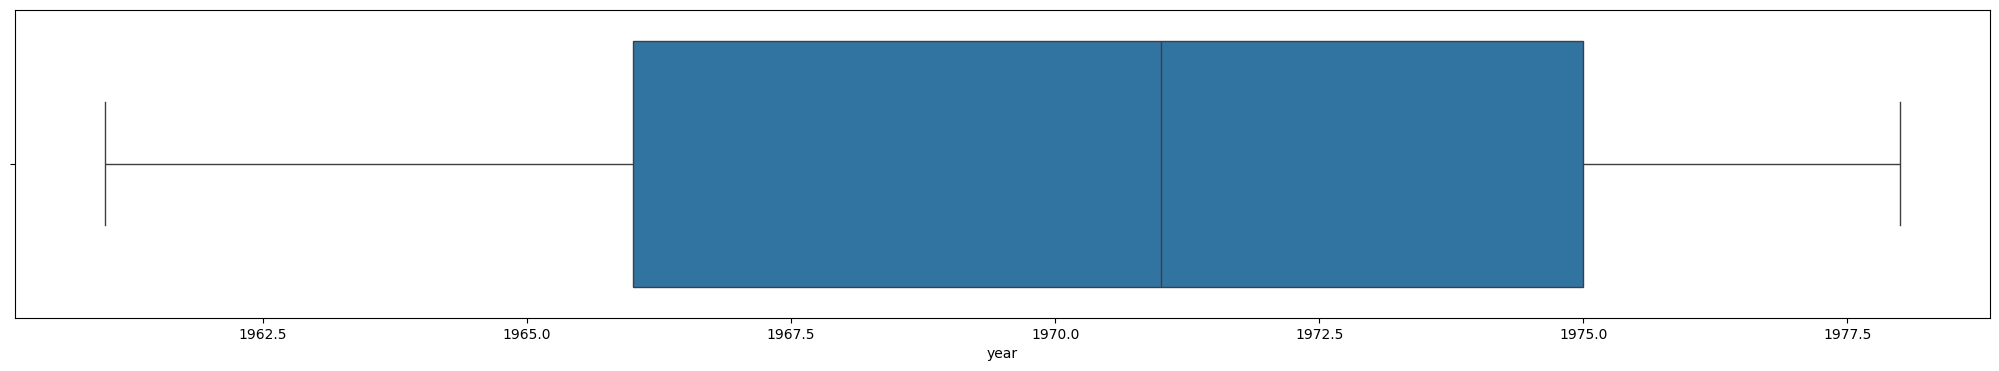

In [ ]:
Numeric=df.drop('DATE',axis=1)
index=0
for feature in Numeric.columns:
    index+=1
    plt.figure(figsize=(40,40))
    plt.subplot((len(Numeric.columns)),2,index)
    sns.boxplot(x=feature,data=Numeric,whis=3)

    plt.tight_layout()

    plt.show()

In [ ]:
# finding outliers.
def find_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
    outlier_count = is_outlier.sum()
    return is_outlier,outlier_count

is_outlier,outlier_count = find_outliers_iqr(Numeric)
print(outlier_count)

WIND        54
IND        597
RAIN       626
IND.1       36
T.MAX        0
IND.2      511
T.MIN        8
T.MIN.G      4
day          0
month        0
year         0
dtype: int64


It’s prudent to ensure that the outliers you identify are genuinely problematic before deciding to remove them. So because we don't have any evidence for it we don't remove any data.

### Wind Speed vs Date Plot

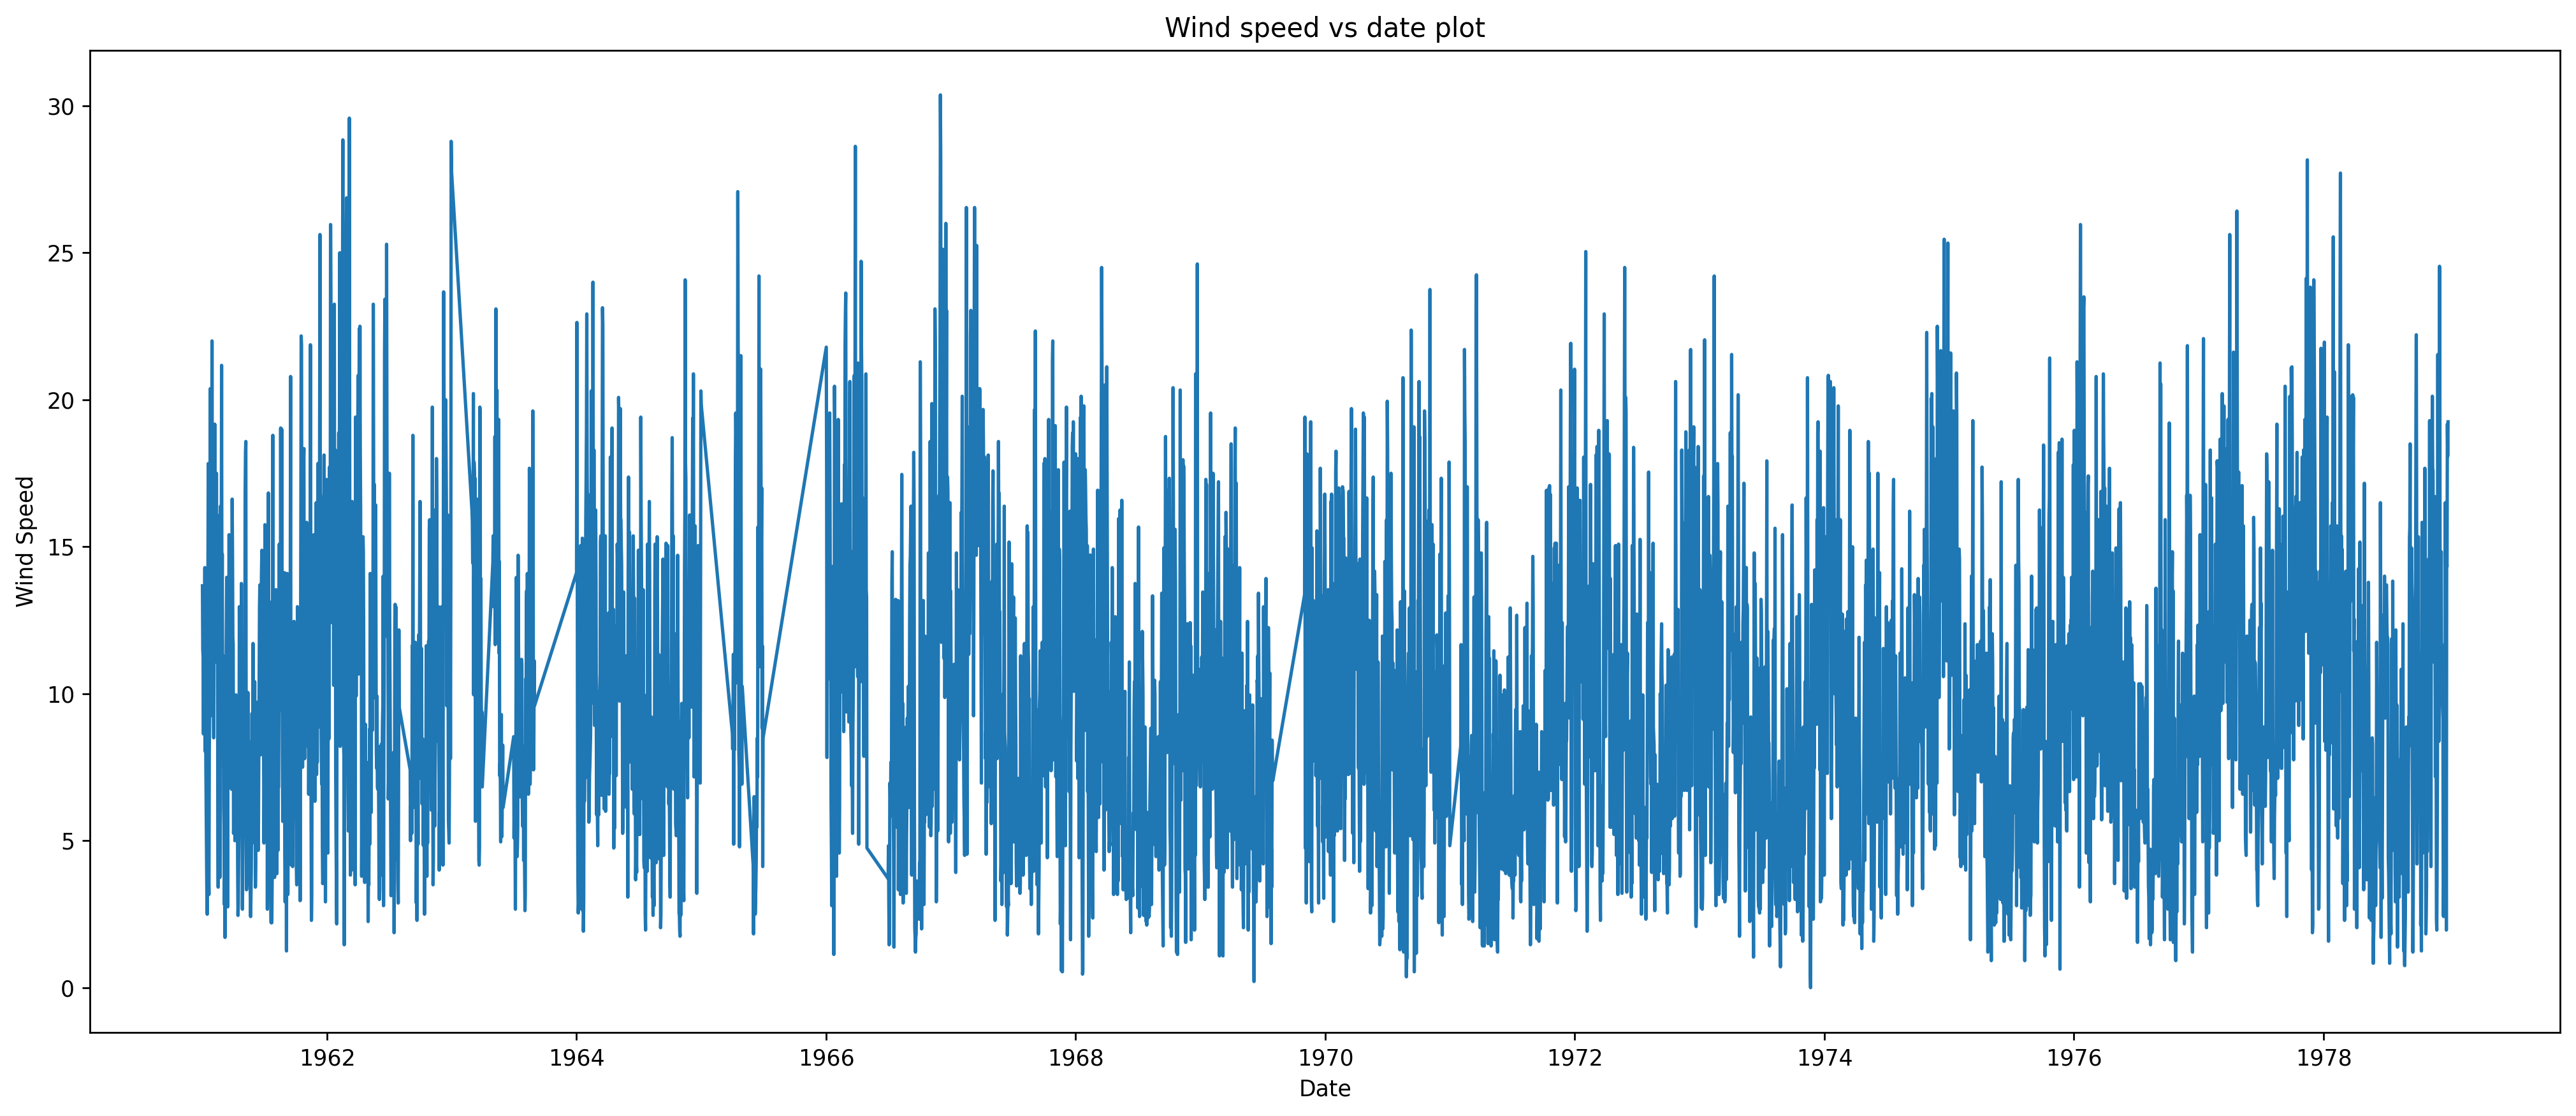

In [ ]:
plt.figure(figsize=(20,8),dpi=250)
plt.plot(df['DATE'],df['WIND'])
plt.title('Wind speed vs date plot')
plt.xlabel('Date')
plt.ylabel('Wind Speed')
plt.show()

### Wind Speed (Yearly)

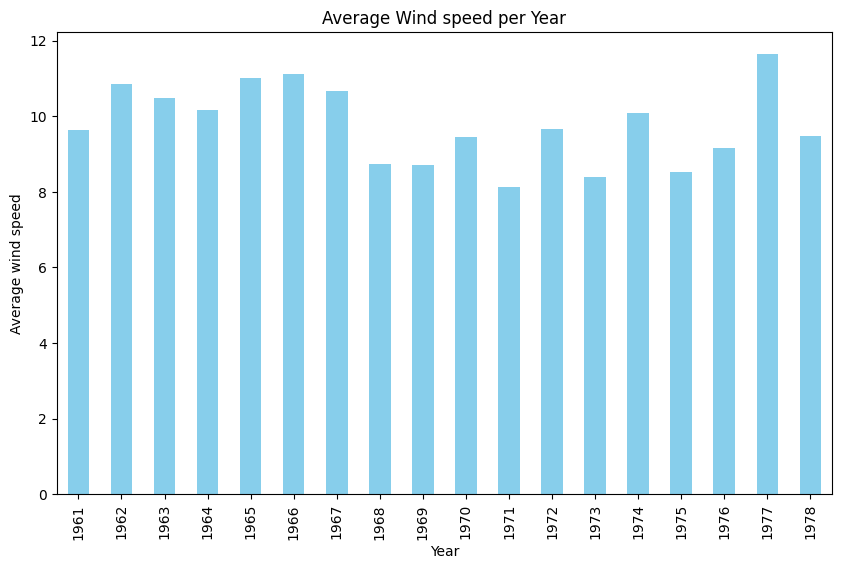

In [ ]:
yearly_avg_power = df.groupby(df['DATE'].dt.year)['WIND'].mean()

plt.figure(figsize=(10, 6))
yearly_avg_power.plot(kind='bar', color='skyblue')


plt.title('Average Wind speed per Year')
plt.xlabel('Year')
plt.ylabel('Average wind speed')

plt.show()


Observation: it is obvious that the wind speed in 1977 was higher than other years.

### Wind Speed (Monthly)

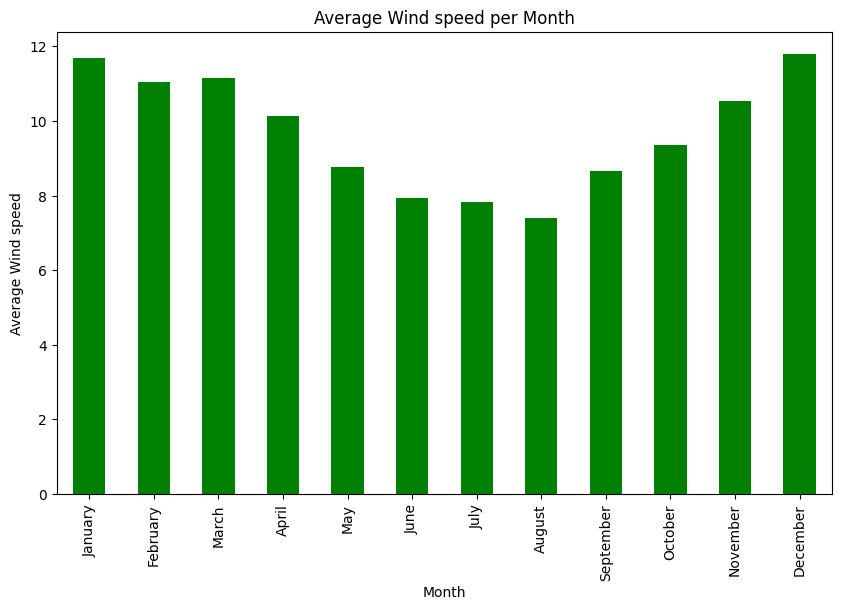

In [ ]:
monthly_speed = df.groupby('month')['WIND'].mean()

monthly_speed.index = [calendar.month_name[m] for m in monthly_speed.index]


plt.figure(figsize=(10, 6))
monthly_speed.plot(kind='bar', color='green')


plt.title('Average Wind speed per Month')
plt.xlabel('Month')
plt.ylabel('Average Wind speed')

plt.show()

Observation：it is clear that wind speed is higher between November and March.

### Wind Speed (Seasonal)

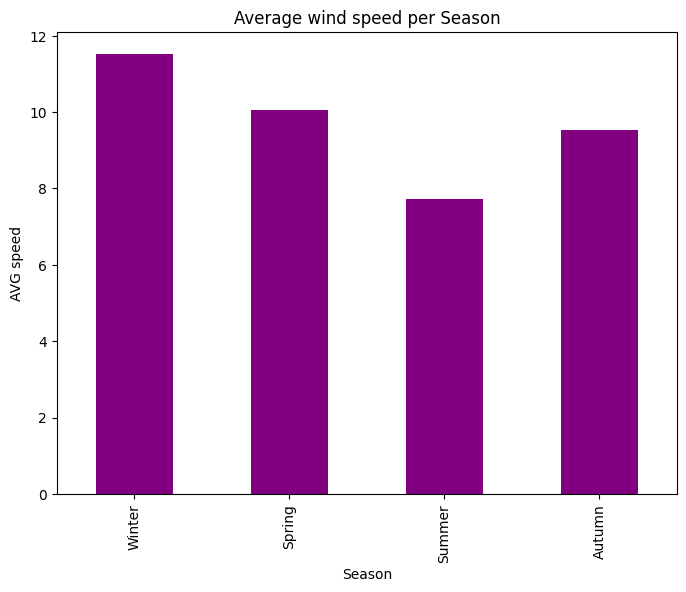

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'

df['Season'] = df['month'].apply(get_season)

seasonal_speed = df.groupby('Season')['WIND'].mean()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_speed = seasonal_speed.reindex(season_order)

plt.figure(figsize=(8, 6))
seasonal_speed.plot(kind='bar', color='purple')

plt.title('Average wind speed per Season')
plt.xlabel('Season')
plt.ylabel('AVG speed')
plt.show()

df=df.drop(columns=['Season'],index=1)

Observation：it is clear that wind speed is lowest during the summer.

### Target distribution plot

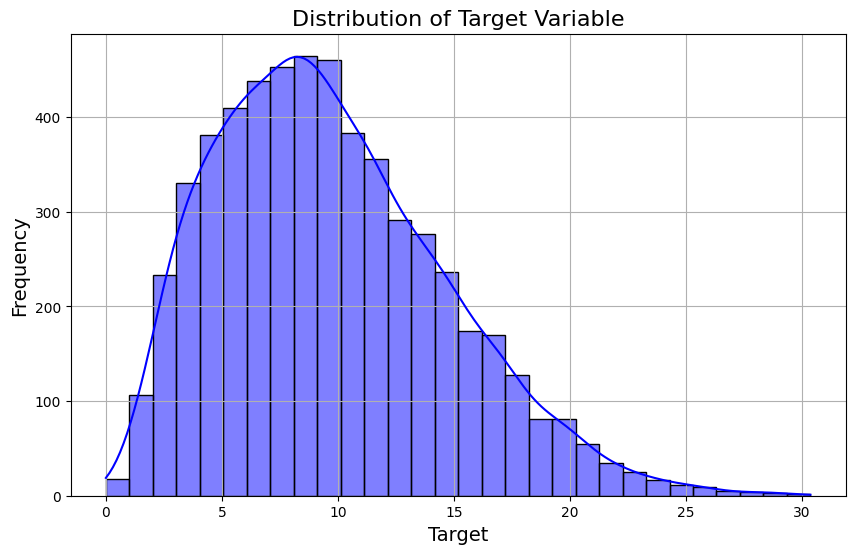

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['WIND'], kde=True, bins=30, color='blue')

plt.title('Distribution of Target Variable', fontsize=16)
plt.xlabel('Target', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(True)
plt.show()

# Data Enhancements


In [ ]:
df=df.drop(columns=['IND', 'RAIN', 'IND.1', 'day', 'month', 'year'],axis=1)

## Vanilla

In [ ]:
df=pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1/wind_dataset.csv')
df=df.drop(columns=['DATE'],axis=1)
y=df['WIND']
x=df.drop(columns=['WIND'],axis=1)

x_train_va, x_test_va, y_train_va, y_test_va = train_test_split(x, y, test_size=0.20, random_state=42)

## Adding Noise


Noise Level (std): 0.01
Original vs Noisy Data Statistics:

Feature: IND
Original - Mean: 0.3795, Std: 1.1626
Noisy - Mean: 0.3793, Std: 1.1627

Feature: RAIN
Original - Mean: 1.8965, Std: 4.0381
Noisy - Mean: 1.8966, Std: 4.0384

Feature: IND.1
Original - Mean: 0.3624, Std: 1.1356
Noisy - Mean: 0.3623, Std: 1.1358

Feature: T.MAX
Original - Mean: 13.3610, Std: 4.9323
Noisy - Mean: 13.3608, Std: 4.9324

Feature: IND.2
Original - Mean: 0.4659, Std: 1.1797
Noisy - Mean: 0.4661, Std: 1.1799

Feature: T.MIN
Original - Mean: 6.4193, Std: 4.6741
Noisy - Mean: 6.4194, Std: 4.6743

Feature: T.MIN.G
Original - Mean: 2.7473, Std: 5.5908
Noisy - Mean: 2.7470, Std: 5.5907

Noise Level (std): 0.05
Original vs Noisy Data Statistics:

Feature: IND
Original - Mean: 0.3795, Std: 1.1626
Noisy - Mean: 0.3807, Std: 1.1634

Feature: RAIN
Original - Mean: 1.8965, Std: 4.0381
Noisy - Mean: 1.8959, Std: 4.0385

Feature: IND.1
Original - Mean: 0.3624, Std: 1.1356
Noisy - Mean: 0.3625, Std: 1.1364

Feature: T.

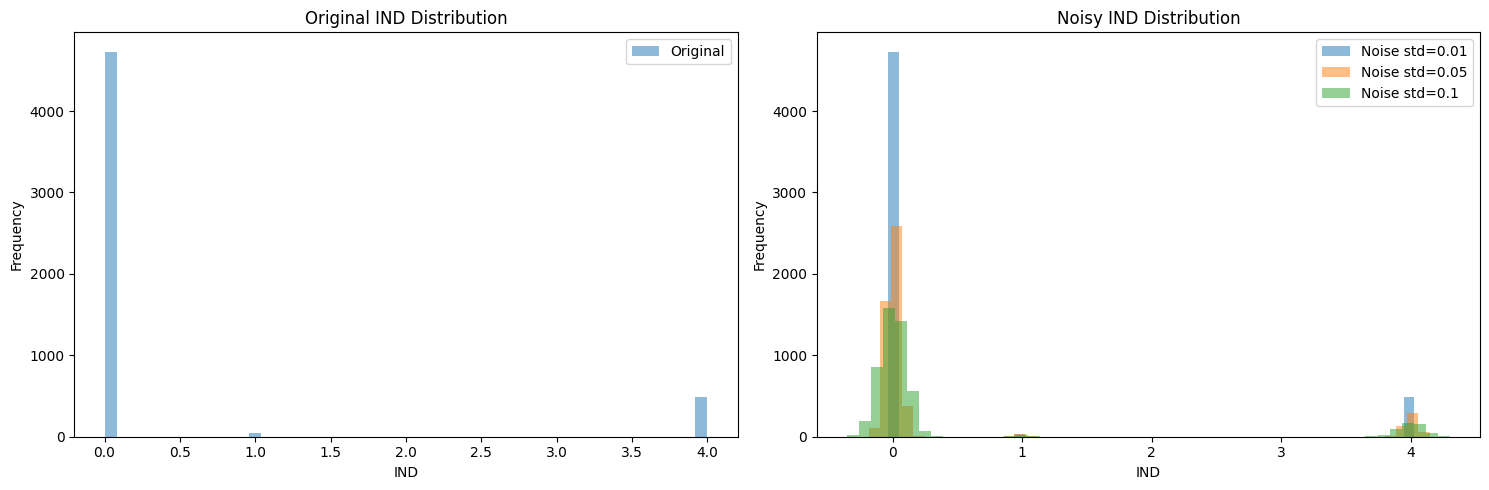

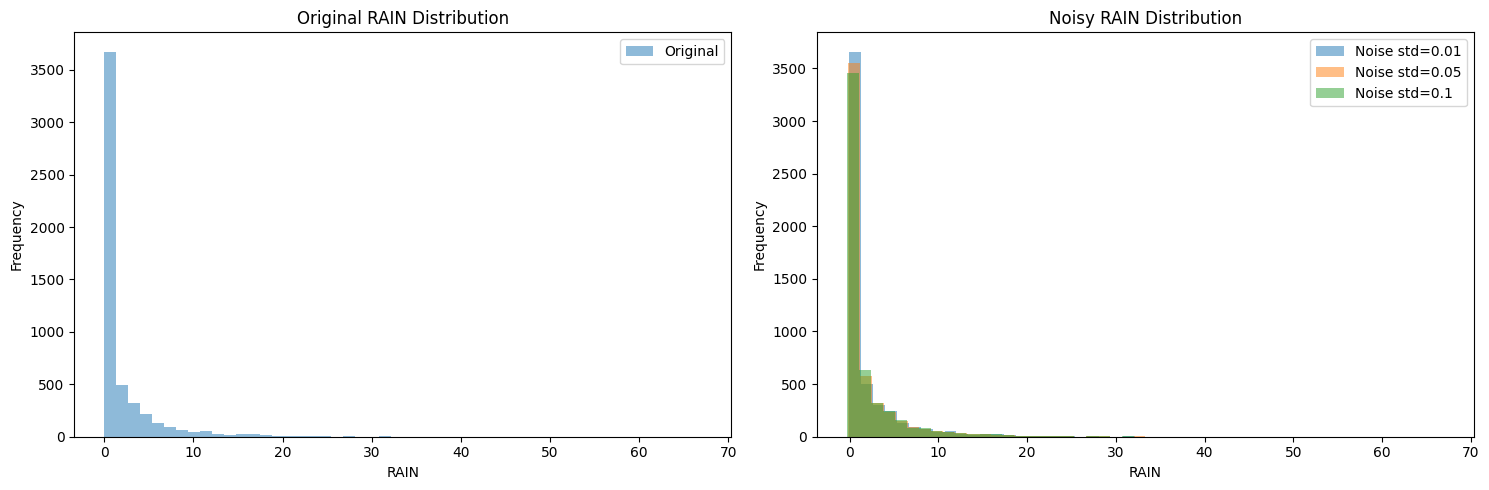

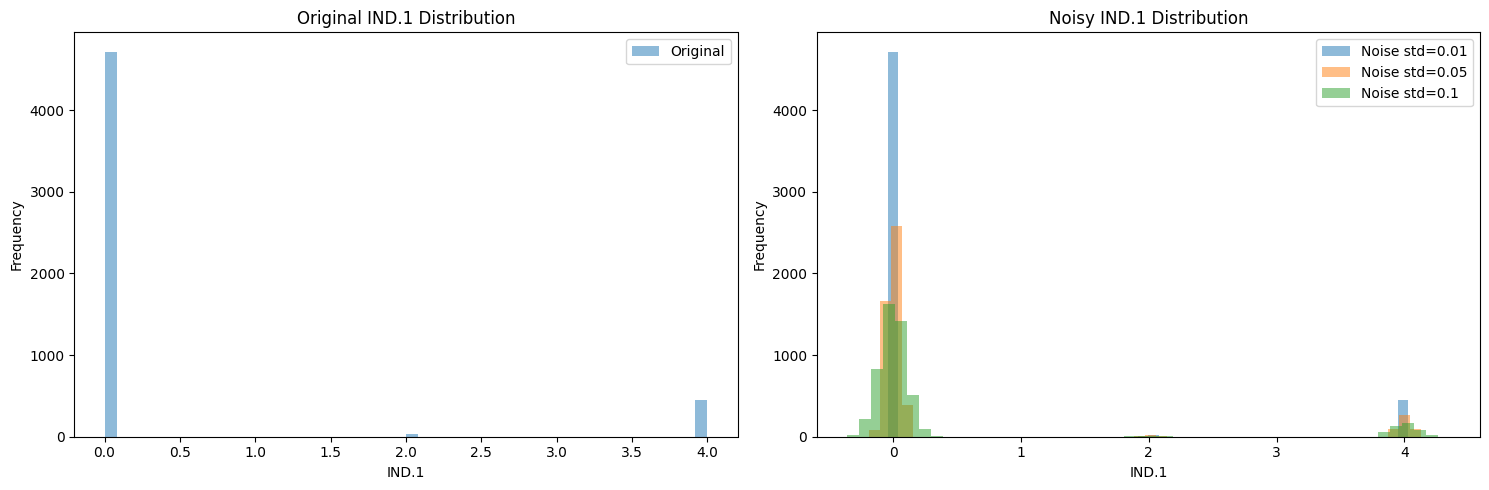

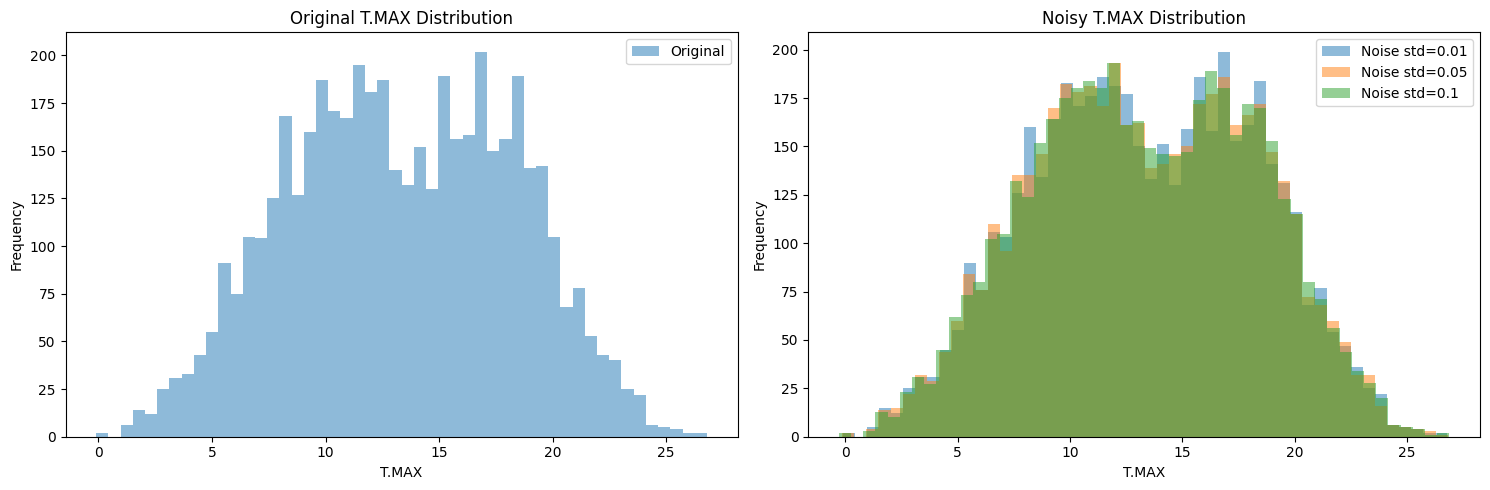

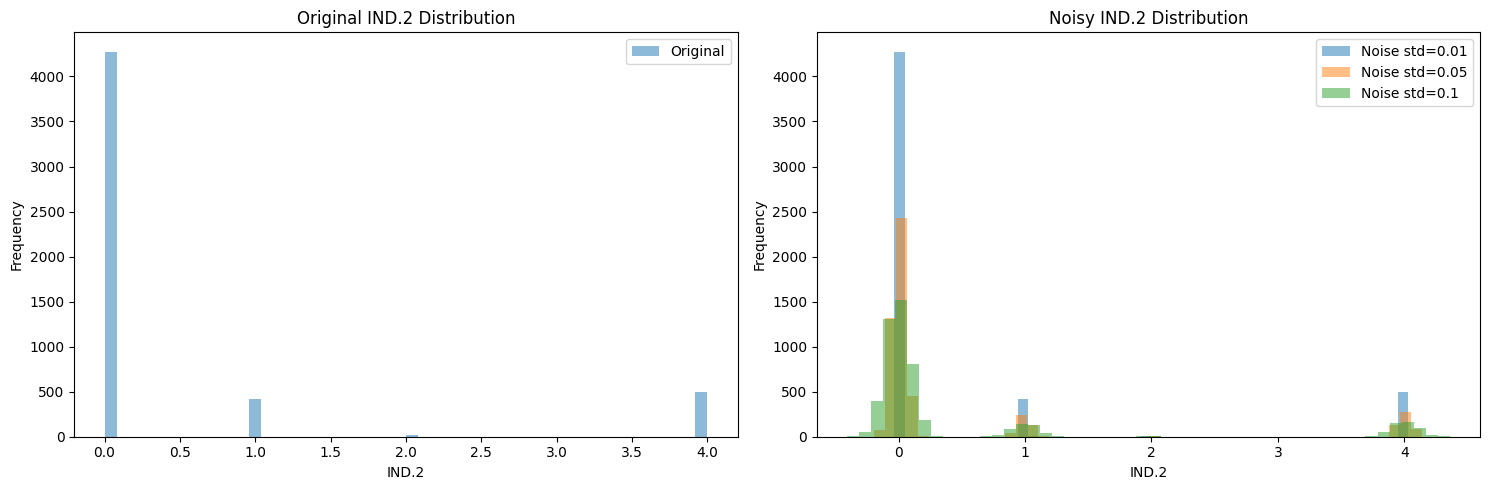

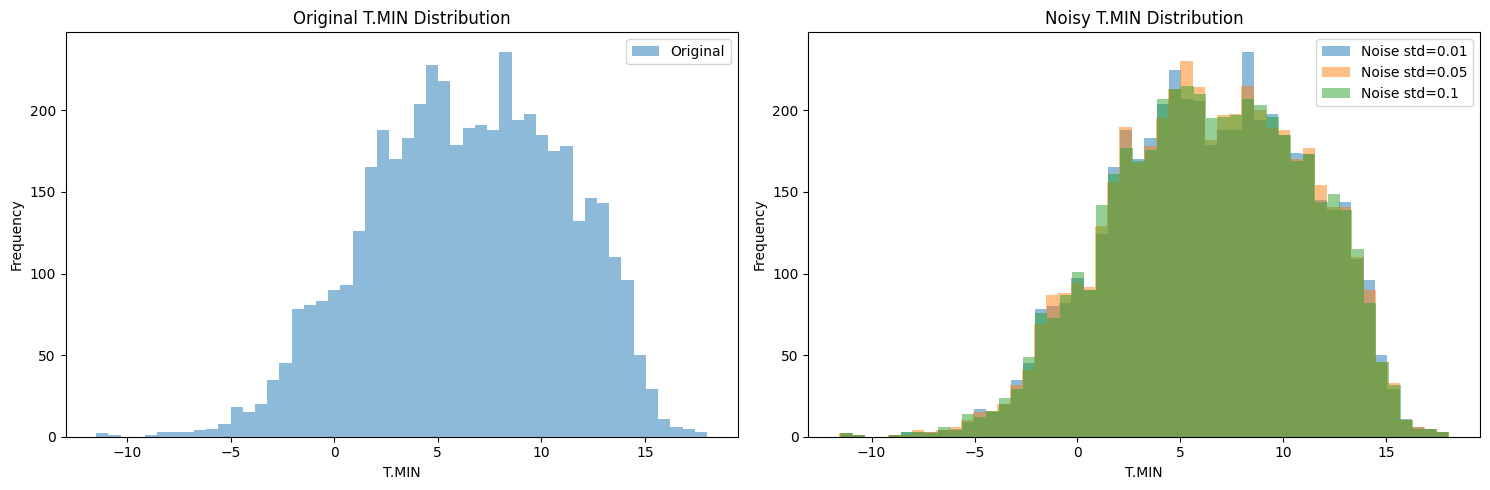

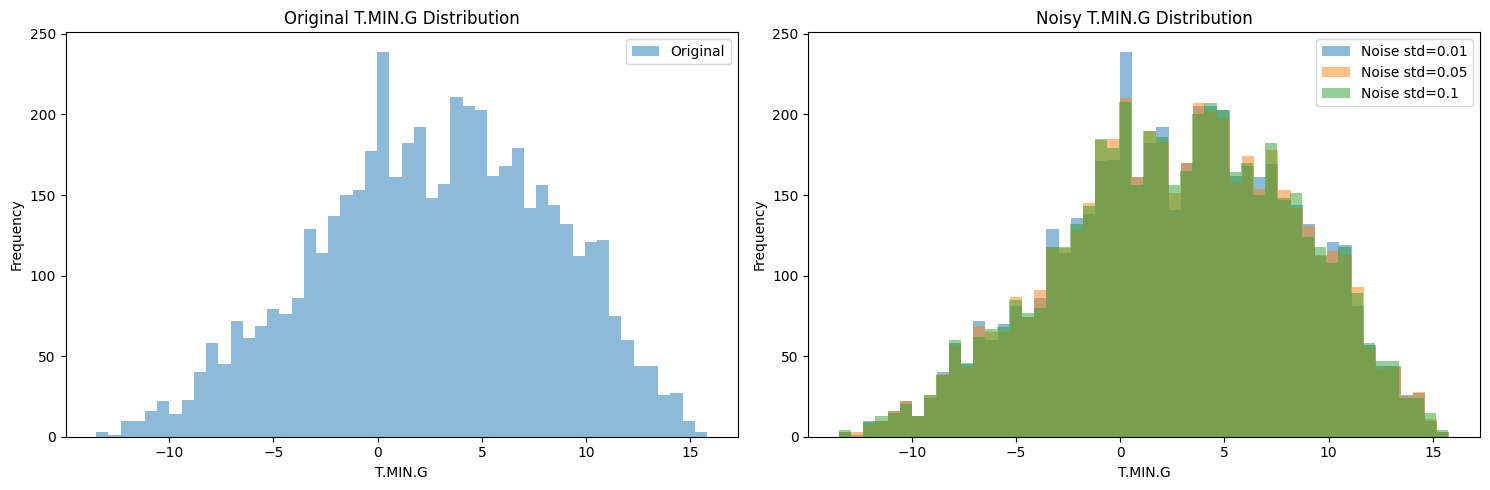

In [ ]:
df=pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1/wind_dataset.csv')

df=df.drop(columns=['DATE'],axis=1)
y=df['WIND']
x=df.drop(columns=['WIND'],axis=1)

x_train, x_test, y_train_no, y_test_no = train_test_split(x, y, test_size=0.20, random_state=42)

def add_gaussian_noise(data, mean=0, std=0.01):
    """
    Add Gaussian noise to the data
    Parameter:
        data: Raw data
        mean: The mean value of the noise
        std: Standard deviation of noise
    """
    noise = np.random.normal(mean, std, data.shape)
    noisy_data = data + noise
    return noisy_data

# Different noise standard deviations
noise_levels = [0.01, 0.05, 0.1]  #

# Store data for different noise levels
noisy_data_sets = []

for noise_level in noise_levels:
    # add noise for dataset
    x_train_noisy = add_gaussian_noise(x_train.values, std=noise_level)
    x_test_noisy = add_gaussian_noise(x_test.values, std=noise_level)

    # numpy to DataFrame
    x_train_noisy = pd.DataFrame(x_train_noisy, columns=x_train.columns)
    x_test_noisy = pd.DataFrame(x_test_noisy, columns=x_test.columns)

    noisy_data_sets.append((x_train_noisy, x_test_noisy))

    # print statistical information
    print(f"\nNoise Level (std): {noise_level}")
    print("Original vs Noisy Data Statistics:")
    for col in x_train.columns:
        print(f"\nFeature: {col}")
        print(f"Original - Mean: {x_train[col].mean():.4f}, Std: {x_train[col].std():.4f}")
        print(f"Noisy - Mean: {x_train_noisy[col].mean():.4f}, Std: {x_train_noisy[col].std():.4f}")


# visualization
def plot_original_vs_noisy(original_data, noisy_data_list, noise_levels, feature_name):
    plt.figure(figsize=(15, 5))

    # plot original data
    plt.subplot(1, 2, 1)
    plt.hist(original_data[feature_name], bins=50, alpha=0.5, label='Original')
    plt.title(f'Original {feature_name} Distribution')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency')
    plt.legend()

    # plot noised data
    plt.subplot(1, 2, 2)
    for noisy_data, noise_level in zip(noisy_data_list, noise_levels):
        plt.hist(noisy_data[feature_name], bins=50, alpha=0.5,
                label=f'Noise std={noise_level}')
    plt.title(f'Noisy {feature_name} Distribution')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot a distribution for each feature
for feature in x_train.columns:
    plot_original_vs_noisy(x_train,
                          [noisy_data[0] for noisy_data in noisy_data_sets],
                          noise_levels,
                          feature)

# Select a dataset of noise levels for training
noise_level_idx = 1
x_train_no, x_test_no = noisy_data_sets[noise_level_idx]

## Time Shifting

In [ ]:
# 读取数据
df = pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1/wind_dataset.csv')

# 1. 转换日期列
df['DATE'] = pd.to_datetime(df['DATE'])

# 2. 创建时间偏移特征
def create_time_shifted_features(df, shift_days=[1, 2], features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']):
    """创建时间偏移特征"""
    df_shifted = df.copy()

    for feature in features:
        for day in shift_days:
            # 直接使用shift，不使用groupby
            df_shifted[f'{feature}_lag_{day}d'] = df_shifted[feature].shift(day)

    return df_shifted

# 3. 创建滑动窗口特征
def create_rolling_features(df, windows=[3], features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']):
    """创建滑动窗口特征"""
    df_rolling = df.copy()

    for feature in features:
        for window in windows:
            # 计算滑动统计量
            df_rolling[f'{feature}_rolling_mean_{window}d'] = df_rolling[feature].rolling(
                window=window, min_periods=1).mean()
            df_rolling[f'{feature}_rolling_std_{window}d'] = df_rolling[feature].rolling(
                window=window, min_periods=1).std()

    return df_rolling

# 4. 特征工程流程
print("Original data shape:", df.shape)

# 创建时间偏移特征
df_shifted = create_time_shifted_features(df,
                                        shift_days=[1, 2],
                                        features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND'])
print("After shifting shape:", df_shifted.shape)

# 创建滑动窗口特征
df_with_features = create_rolling_features(df_shifted,
                                         windows=[3],
                                         features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND'])
print("After rolling features shape:", df_with_features.shape)

# 5. 处理缺失值
# 检查缺失值
print("\nMissing values before handling:")
print(df_with_features.isnull().sum())

# 使用前向填充
df_with_features = df_with_features.fillna(method='ffill')
# 使用后向填充处理剩余的NaN
df_with_features = df_with_features.fillna(method='bfill')

# 再次检查缺失值
print("\nMissing values after handling:")
print(df_with_features.isnull().sum())

# 6. 准备数据集
# 选择特征
feature_columns = [col for col in df_with_features.columns
                  if col not in ['DATE', 'WIND']]

X = df_with_features[feature_columns]
y = df_with_features['WIND']

# 7. 数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 8. 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42)

# 9. 打印最终形状
print("\nFinal shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 10. 检查数据质量
print("\nData quality check:")
print("Number of NaN values in X_train:", X_train.isnull().sum().sum())
print("Number of NaN values in X_test:", X_test.isnull().sum().sum())
print("Number of NaN values in y_train:", y_train.isnull().sum())
print("Number of NaN values in y_test:", y_test.isnull().sum())

# 11. 可视化特征
def plot_feature_distributions(X_train, feature_names=None, n_cols=3):
    if feature_names is None:
        feature_names = X_train.columns

    n_features = len(feature_names)
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(15, 5 * n_rows))

    for i, feature in enumerate(feature_names):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.hist(X_train[feature], bins=50)
        plt.title(f'Distribution of {feature}')
        plt.xlabel('Value')


x_train_ti=X_train
x_test_ti=X_test
y_train_ti=y_train
y_test_ti=y_test

Original data shape: (6574, 9)
After shifting shape: (6574, 17)
After rolling features shape: (6574, 25)

Missing values before handling:
DATE                         0
WIND                         0
IND                          0
RAIN                         0
IND.1                       61
T.MAX                      621
IND.2                       61
T.MIN                      674
T.MIN.G                    360
T.MAX_lag_1d               622
T.MAX_lag_2d               623
T.MIN_lag_1d               675
T.MIN_lag_2d               676
T.MIN.G_lag_1d             361
T.MIN.G_lag_2d             362
WIND_lag_1d                  1
WIND_lag_2d                  2
T.MAX_rolling_mean_3d      593
T.MAX_rolling_std_3d       618
T.MIN_rolling_mean_3d      644
T.MIN_rolling_std_3d       671
T.MIN.G_rolling_mean_3d    187
T.MIN.G_rolling_std_3d     218
WIND_rolling_mean_3d         0
WIND_rolling_std_3d          1
dtype: int64

Missing values after handling:
DATE                       0
WIND         

## Confusion of Adding Noise and Time Shifting

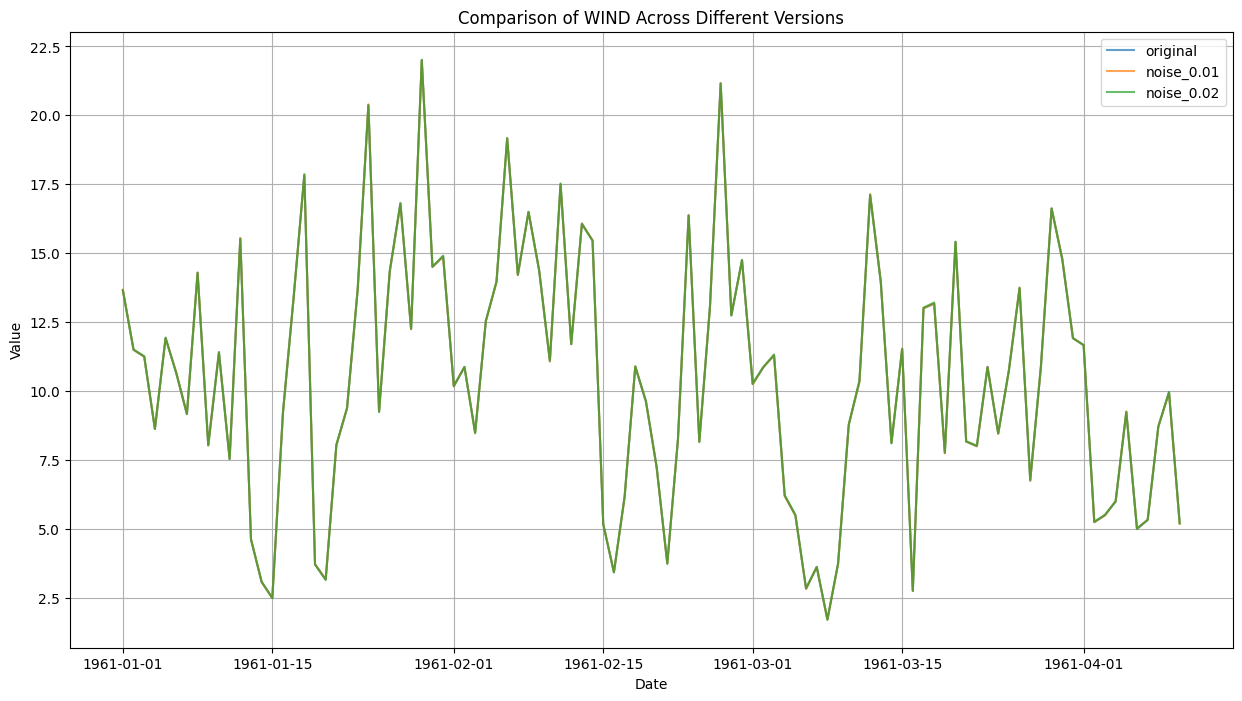


Dataset: original
X_train shape: (5259, 23)
X_test shape: (1315, 23)

Dataset: noise_0.01
X_train shape: (5259, 23)
X_test shape: (1315, 23)

Dataset: noise_0.02
X_train shape: (5259, 23)
X_test shape: (1315, 23)

Data quality check for original:
Number of NaN values:
X_train: 42072
X_test: 10520
y_train: 0
y_test: 0

Value ranges:

IND:
Train - min: 0.00, max: 4.00
Test  - min: 0.00, max: 4.00

RAIN:
Train - min: 0.00, max: 67.00
Test  - min: 0.00, max: 44.40

IND.1:
Train - min: 0.00, max: 4.00
Test  - min: 0.00, max: 4.00

T.MAX:
Train - min: -0.10, max: 26.80
Test  - min: 0.80, max: 24.70

IND.2:
Train - min: 0.00, max: 4.00
Test  - min: 0.00, max: 4.00

T.MIN:
Train - min: -11.50, max: 18.00
Test  - min: -6.00, max: 17.80

T.MIN.G:
Train - min: -13.50, max: 15.80
Test  - min: -14.40, max: 15.40

T.MAX_lag_1d:
Train - min: nan, max: nan
Test  - min: nan, max: nan

T.MAX_lag_2d:
Train - min: nan, max: nan
Test  - min: nan, max: nan

T.MIN_lag_1d:
Train - min: nan, max: nan
Test  - 

In [ ]:
# 读取数据
df = pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/wind-speed-prediction-dataset/versions/1/wind_dataset.csv')

# 1. 保留DATE列的原始数据
df_with_date = df.copy()
df_with_date['DATE'] = pd.to_datetime(df_with_date['DATE'])

# 2. 定义添加高斯噪声的函数
def add_gaussian_noise(data, mean=0, std=0.01):
    """添加高斯噪声"""
    noise = np.random.normal(mean, std, data.shape)
    noisy_data = data + noise
    return noisy_data

# 3. 定义时间偏移特征函数
def create_time_shifted_features(df, shift_days=[1, 2], features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']):
    """创建时间偏移特征"""
    df_shifted = df.copy()

    for feature in features:
        for day in shift_days:
            # 滞后特征
            df_shifted[f'{feature}_lag_{day}d'] = df_shifted.groupby(df_shifted.index)[feature].shift(day)

    return df_shifted

# 4. 定义滑动窗口特征函数
def create_rolling_features(df, windows=[3], features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']):
    """创建滑动窗口特征"""
    df_rolling = df.copy()

    for feature in features:
        for window in windows:
            df_rolling[f'{feature}_rolling_mean_{window}d'] = df_rolling[feature].rolling(window=window, min_periods=1).mean()
            df_rolling[f'{feature}_rolling_std_{window}d'] = df_rolling[feature].rolling(window=window, min_periods=1).std()

    return df_rolling

# 5. 创建带噪声和时间特征的数据集
def create_augmented_dataset(df, noise_levels=[0.01, 0.02],
                           shift_days=[1, 2],
                           windows=[3],
                           features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']):
    """创建增强数据集"""
    augmented_dfs = []

    # 原始数据集
    df_original = df.copy()
    augmented_dfs.append(('original', df_original))

    # 添加噪声的数据集
    for noise_level in noise_levels:
        df_noisy = df.copy()
        for feature in features:
            df_noisy[feature] = add_gaussian_noise(df_noisy[feature].values, std=noise_level)
        augmented_dfs.append((f'noise_{noise_level}', df_noisy))

    # 为每个版本添加时间特征
    final_dfs = []
    for name, curr_df in augmented_dfs:
        # 添加时间偏移特征
        df_with_time = create_time_shifted_features(curr_df, shift_days, features)
        # 添加滑动窗口特征
        df_with_time = create_rolling_features(df_with_time, windows, features)
        # 处理NaN
        df_with_time = df_with_time.fillna(method='ffill').fillna(method='bfill')
        final_dfs.append((name, df_with_time))

    return final_dfs

# create augmented datasets
augmented_datasets = create_augmented_dataset(
    df_with_date,
    noise_levels=[0.01, 0.02],
    shift_days=[1, 2],
    windows=[3],
    features=['T.MAX', 'T.MIN', 'T.MIN.G', 'WIND']
)

# visualization
def plot_feature_comparison(datasets, feature='WIND', sample_size=100):
    plt.figure(figsize=(15, 8))

    for name, df in datasets:
        plt.plot(df['DATE'][:sample_size],
                df[feature][:sample_size],
                label=name,
                alpha=0.7)

    plt.title(f'Comparison of {feature} Across Different Versions')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# plot comparison map
plot_feature_comparison(augmented_datasets)

# 8. 准备训练数据
def prepare_training_data(df, target='WIND'):
    y = df[target]
    X = df.drop([target, 'DATE'], axis=1)
    return train_test_split(X, y, test_size=0.2, random_state=42)


training_sets = {}
for name, df in augmented_datasets:
    x_train, x_test, y_train, y_test = prepare_training_data(df)
    training_sets[name] = (x_train, x_test, y_train, y_test)
    print(f"\nDataset: {name}")
    print(f"X_train shape: {x_train.shape}")
    print(f"X_test shape: {x_test.shape}")

# data quality check
def check_data_quality(name, x_train, x_test, y_train, y_test):
    print(f"\nData quality check for {name}:")
    print("Number of NaN values:")
    print(f"X_train: {x_train.isna().sum().sum()}")
    print(f"X_test: {x_test.isna().sum().sum()}")
    print(f"y_train: {y_train.isna().sum()}")
    print(f"y_test: {y_test.isna().sum()}")

    print("\nValue ranges:")
    for col in x_train.columns:
        print(f"\n{col}:")
        print(f"Train - min: {x_train[col].min():.2f}, max: {x_train[col].max():.2f}")
        print(f"Test  - min: {x_test[col].min():.2f}, max: {x_test[col].max():.2f}")

# dataset quality check
for name, (x_train, x_test, y_train, y_test) in training_sets.items():
    check_data_quality(name, x_train, x_test, y_train, y_test)

# use noise_0.01 dataset for train
x_train_co, x_test_co, y_train_co, y_test_co = training_sets['noise_0.01']

## Standarization

In [ ]:
# 1. 数据检查函数
from sklearn.preprocessing import RobustScaler, StandardScaler
import numpy as np
import pandas as pd
def check_data_issues(data, name):
    print(f"\nChecking {name}:")
    print(f"Shape: {data.shape}")
    print(f"NaN values: {np.isnan(data).sum()}")
    print(f"Inf values: {np.isinf(data).sum()}")
    print(f"Min value: {np.nanmin(data) if not np.all(np.isnan(data)) else 'All NaN'}")
    print(f"Max value: {np.nanmax(data) if not np.all(np.isnan(data)) else 'All NaN'}")
    print(f"Mean value: {np.nanmean(data) if not np.all(np.isnan(data)) else 'All NaN'}")
    print(f"Std value: {np.nanstd(data) if not np.all(np.isnan(data)) else 'All NaN'}")

# 2. 改进的数据清理函数
def clean_data_improved(data, name=""):
    print(f"\nCleaning {name}...")

    # 确保数据是numpy数组
    if isinstance(data, pd.DataFrame):
        data = data.values

    # 创建数据副本
    cleaned = data.copy().astype(np.float32)

    # 处理inf值
    cleaned[~np.isfinite(cleaned)] = np.nan

    # 对每一列进行处理
    for col in range(cleaned.shape[1]):
        column_data = cleaned[:, col]

        # 计算列的统计量（排除NaN值）
        valid_mask = ~np.isnan(column_data)
        if np.any(valid_mask):
            valid_data = column_data[valid_mask]
            median_val = np.median(valid_data)
            q1 = np.percentile(valid_data, 25)
            q3 = np.percentile(valid_data, 75)
            iqr = q3 - q1

            # 定义异常值边界
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            # 处理异常值
            column_data[column_data < lower_bound] = lower_bound
            column_data[column_data > upper_bound] = upper_bound

            # 使用中位数填充NaN值
            column_data[np.isnan(column_data)] = median_val

        else:
            # 如果整列都是NaN，用0填充
            column_data[:] = 0

        cleaned[:, col] = column_data

    # 最后检查确保没有NaN值
    if np.any(np.isnan(cleaned)):
        print(f"Warning: Still found NaN values in {name} after cleaning")
        cleaned[np.isnan(cleaned)] = 0

    return cleaned

# 3. 改进的标准化函数
def standardize_data(train_data, test_data, name=""):
    print(f"\nStandardizing {name}...")

    # 确保数据没有NaN
    assert not np.any(np.isnan(train_data)), f"Found NaN in {name} training data before standardization"
    assert not np.any(np.isnan(test_data)), f"Found NaN in {name} test data before standardization"

    # 使用RobustScaler代替StandardScaler
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # 检查标准化后的数据
    assert not np.any(np.isnan(train_scaled)), f"Found NaN in {name} training data after standardization"
    assert not np.any(np.isnan(test_scaled)), f"Found NaN in {name} test data after standardization"

    return train_scaled, test_scaled

# 4. 应用数据处理流程
print("Original data check:")
check_data_issues(x_train_co, "x_train_co")
check_data_issues(x_train_va, "x_train_va")
check_data_issues(x_train_no, "x_train_no")
check_data_issues(x_train_ti, "x_train_ti")

# 清理数据
x_train_co_clean = clean_data_improved(x_train_co, "Combined training")
x_test_co_clean = clean_data_improved(x_test_co, "Combined testing")

x_train_va_clean = clean_data_improved(x_train_va, "Vanilla training")
x_test_va_clean = clean_data_improved(x_test_va, "Vanilla testing")

x_train_no_clean = clean_data_improved(x_train_no, "Noise training")
x_test_no_clean = clean_data_improved(x_test_no, "Noise testing")

x_train_ti_clean = clean_data_improved(x_train_ti, "Time-shift training")
x_test_ti_clean = clean_data_improved(x_test_ti, "Time-shift testing")

# 标准化数据
x_train_co, x_test_co = standardize_data(x_train_co_clean, x_test_co_clean, "Combined")
x_train_va, x_test_va = standardize_data(x_train_va_clean, x_test_va_clean, "Vanilla")
x_train_no, x_test_no = standardize_data(x_train_no_clean, x_test_no_clean, "Noise")
x_train_ti, x_test_ti = standardize_data(x_train_ti_clean, x_test_ti_clean, "Time-shift")

# 最终检查
print("\nFinal data check after cleaning and standardization:")
check_data_issues(x_train_co, "x_train_co (final)")
check_data_issues(x_train_va, "x_train_va (final)")
check_data_issues(x_train_no, "x_train_no (final)")
check_data_issues(x_train_ti, "x_train_ti (final)")

Original data check:

Checking x_train_co:
Shape: (5259, 23)
NaN values: IND                           0
RAIN                          0
IND.1                         0
T.MAX                         0
IND.2                         0
T.MIN                         0
T.MIN.G                       0
T.MAX_lag_1d               5259
T.MAX_lag_2d               5259
T.MIN_lag_1d               5259
T.MIN_lag_2d               5259
T.MIN.G_lag_1d             5259
T.MIN.G_lag_2d             5259
WIND_lag_1d                5259
WIND_lag_2d                5259
T.MAX_rolling_mean_3d         0
T.MAX_rolling_std_3d          0
T.MIN_rolling_mean_3d         0
T.MIN_rolling_std_3d          0
T.MIN.G_rolling_mean_3d       0
T.MIN.G_rolling_std_3d        0
WIND_rolling_mean_3d          0
WIND_rolling_std_3d           0
dtype: int64
Inf values: IND                        0
RAIN                       0
IND.1                      0
T.MAX                      0
IND.2                      0
T.MIN                

# CNN Regression model

In [ ]:
results=[]

## CNN basic

Training Vanilla strategy...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training Noise strategy...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training Time-shift strategy...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Training Combined strategy...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


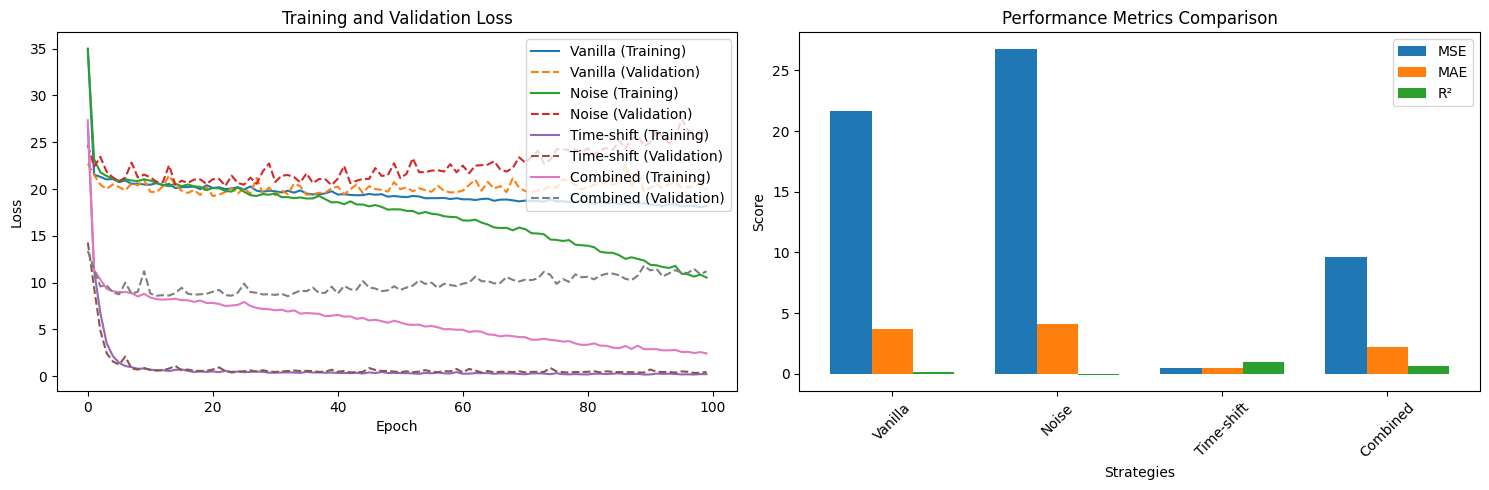

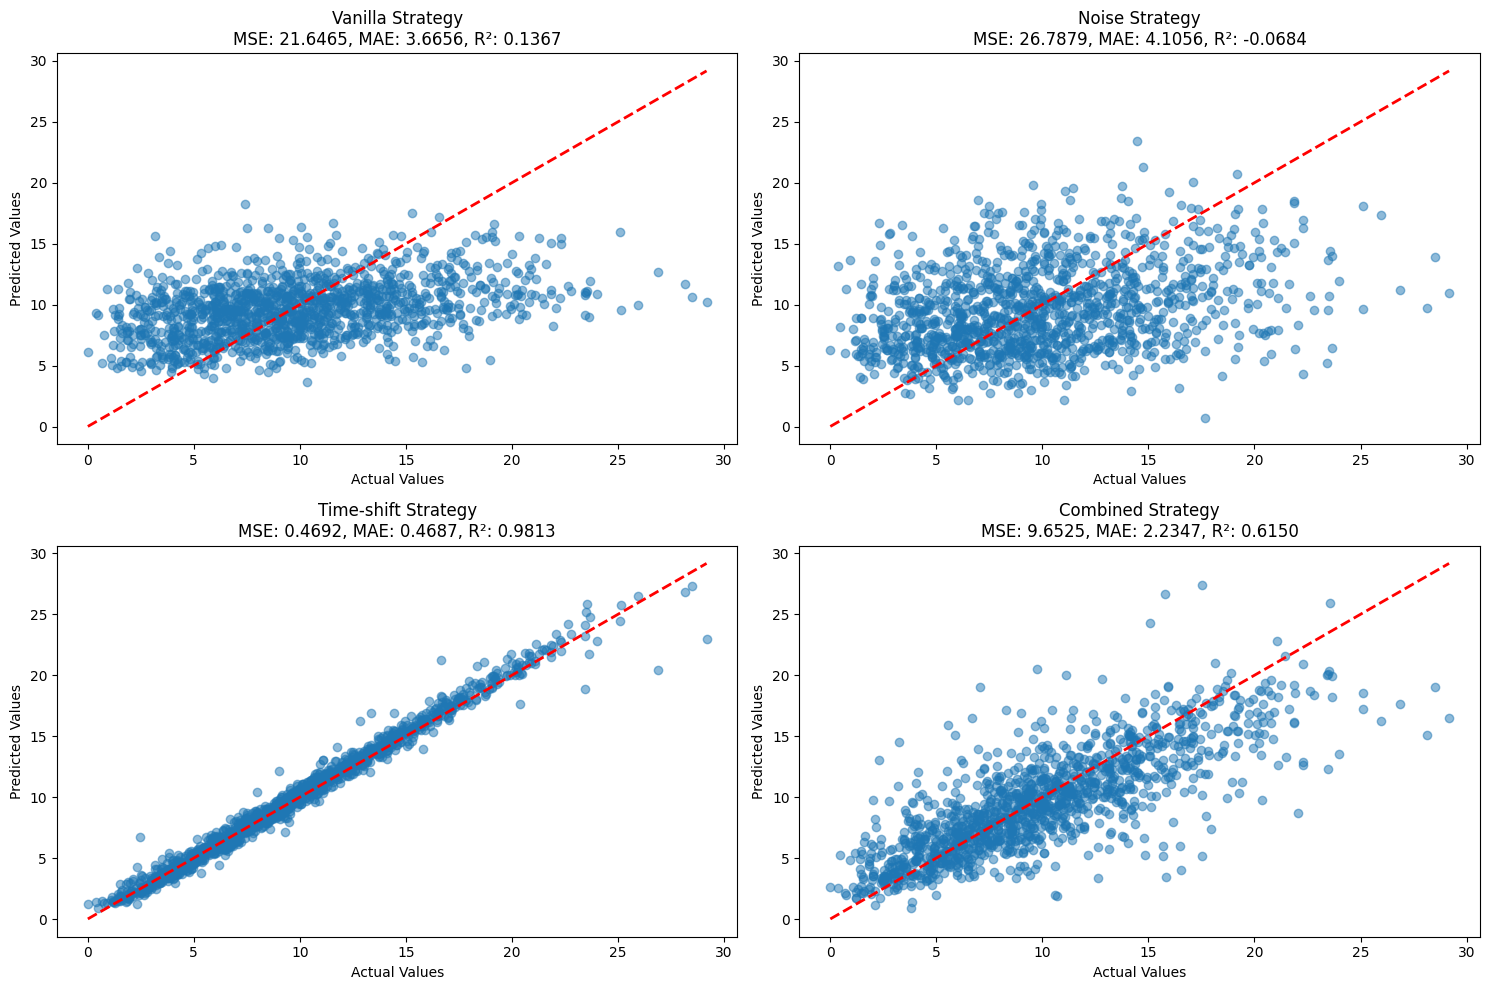

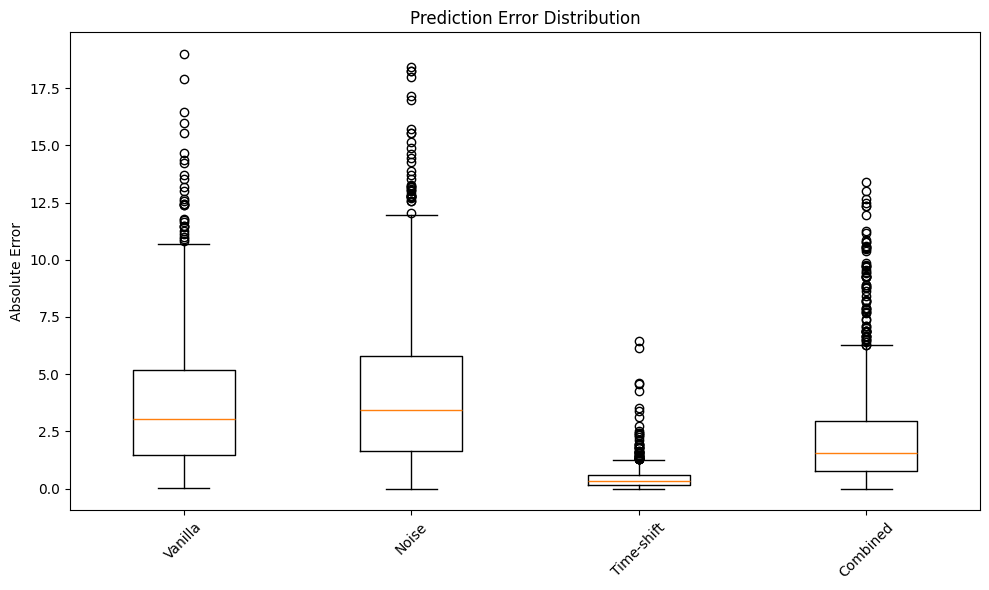


Detailed Results:
--------------------------------------------------

Strategy: Vanilla
MSE: 21.6465
MAE: 3.6656
R²: 0.1367

Strategy: Noise
MSE: 26.7879
MAE: 4.1056
R²: -0.0684

Strategy: Time-shift
MSE: 0.4692
MAE: 0.4687
R²: 0.9813

Strategy: Combined
MSE: 9.6525
MAE: 2.2347
R²: 0.6150


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_and_evaluate_model(x_train, x_test, y_train, y_test, strategy_name):
    # 创建模型
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',padding='same',input_shape=(x_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu',padding='same'))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',padding='same'))
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))

    # 编译模型
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 训练模型
    history = model.fit(x_train, y_train,
                       epochs=10,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=0)

    # 预测
    y_pred = model.predict(x_test)

    # 计算评估指标
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'strategy': strategy_name,
        'history': history.history,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'y_pred': y_pred
    }

# 训练所有策略
strategies = {
    'Vanilla': (x_train_va, x_test_va,y_train_va,y_test_va),
    'Noise': (x_train_no, x_test_no,y_train_no,y_test_no),
    'Time-shift': (x_train_ti, x_test_ti,y_train_ti,y_test_ti),
    'Combined': (x_train_co, x_test_co,y_train_co,y_test_co)
}

results = []
for strategy_name, (x_train, x_test, y_train,y_test) in strategies.items():
    print(f"Training {strategy_name} strategy...")
    result = train_and_evaluate_model(x_train, x_test, y_train, y_test, strategy_name)
    results.append(result)


plt.style.use('default')

# 1. 训练历史对比
plt.figure(figsize=(15, 5))

# 损失曲线对比
plt.subplot(1, 2, 1)
for result in results:
    plt.plot(result['history']['loss'],
             label=f"{result['strategy']} (Training)")
    plt.plot(result['history']['val_loss'],
             linestyle='--',
             label=f"{result['strategy']} (Validation)")
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2. 评估指标对比
metrics = ['mse', 'mae', 'r2']
values = {metric: [result[metric] for result in results] for metric in metrics}
strategies_names = [result['strategy'] for result in results]

plt.subplot(1, 2, 2)
x = np.arange(len(strategies_names))
width = 0.25

plt.bar(x - width, values['mse'], width, label='MSE')
plt.bar(x, values['mae'], width, label='MAE')
plt.bar(x + width, values['r2'], width, label='R²')

plt.xlabel('Strategies')
plt.ylabel('Score')
plt.title('Performance Metrics Comparison')
plt.xticks(x, strategies_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 3. 预测值与实际值对比
plt.figure(figsize=(15, 10))
for i, result in enumerate(results):
    plt.subplot(2, 2, i+1)
    plt.scatter(y_test, result['y_pred'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{result["strategy"]} Strategy\nMSE: {result["mse"]:.4f}, MAE: {result["mae"]:.4f}, R²: {result["r2"]:.4f}')

plt.tight_layout()
plt.show()

# 4. 箱线图对比
plt.figure(figsize=(10, 6))
error_data = []
labels = []
for result in results:
    errors = np.abs(y_test - result['y_pred'].flatten())
    error_data.append(errors)
    labels.extend([result['strategy']] * len(errors))

plt.boxplot(error_data, labels=strategies_names)
plt.title('Prediction Error Distribution')
plt.ylabel('Absolute Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 打印详细结果
print("\nDetailed Results:")
print("-" * 50)
for result in results:
    print(f"\nStrategy: {result['strategy']}")
    print(f"MSE: {result['mse']:.4f}")
    print(f"MAE: {result['mae']:.4f}")
    print(f"R²: {result['r2']:.4f}")

## ShuffleNet

Training ShuffleNet with Vanilla strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
Training ShuffleNet with Noise strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
Training ShuffleNet with Time-shift strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Training ShuffleNet with Combined strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


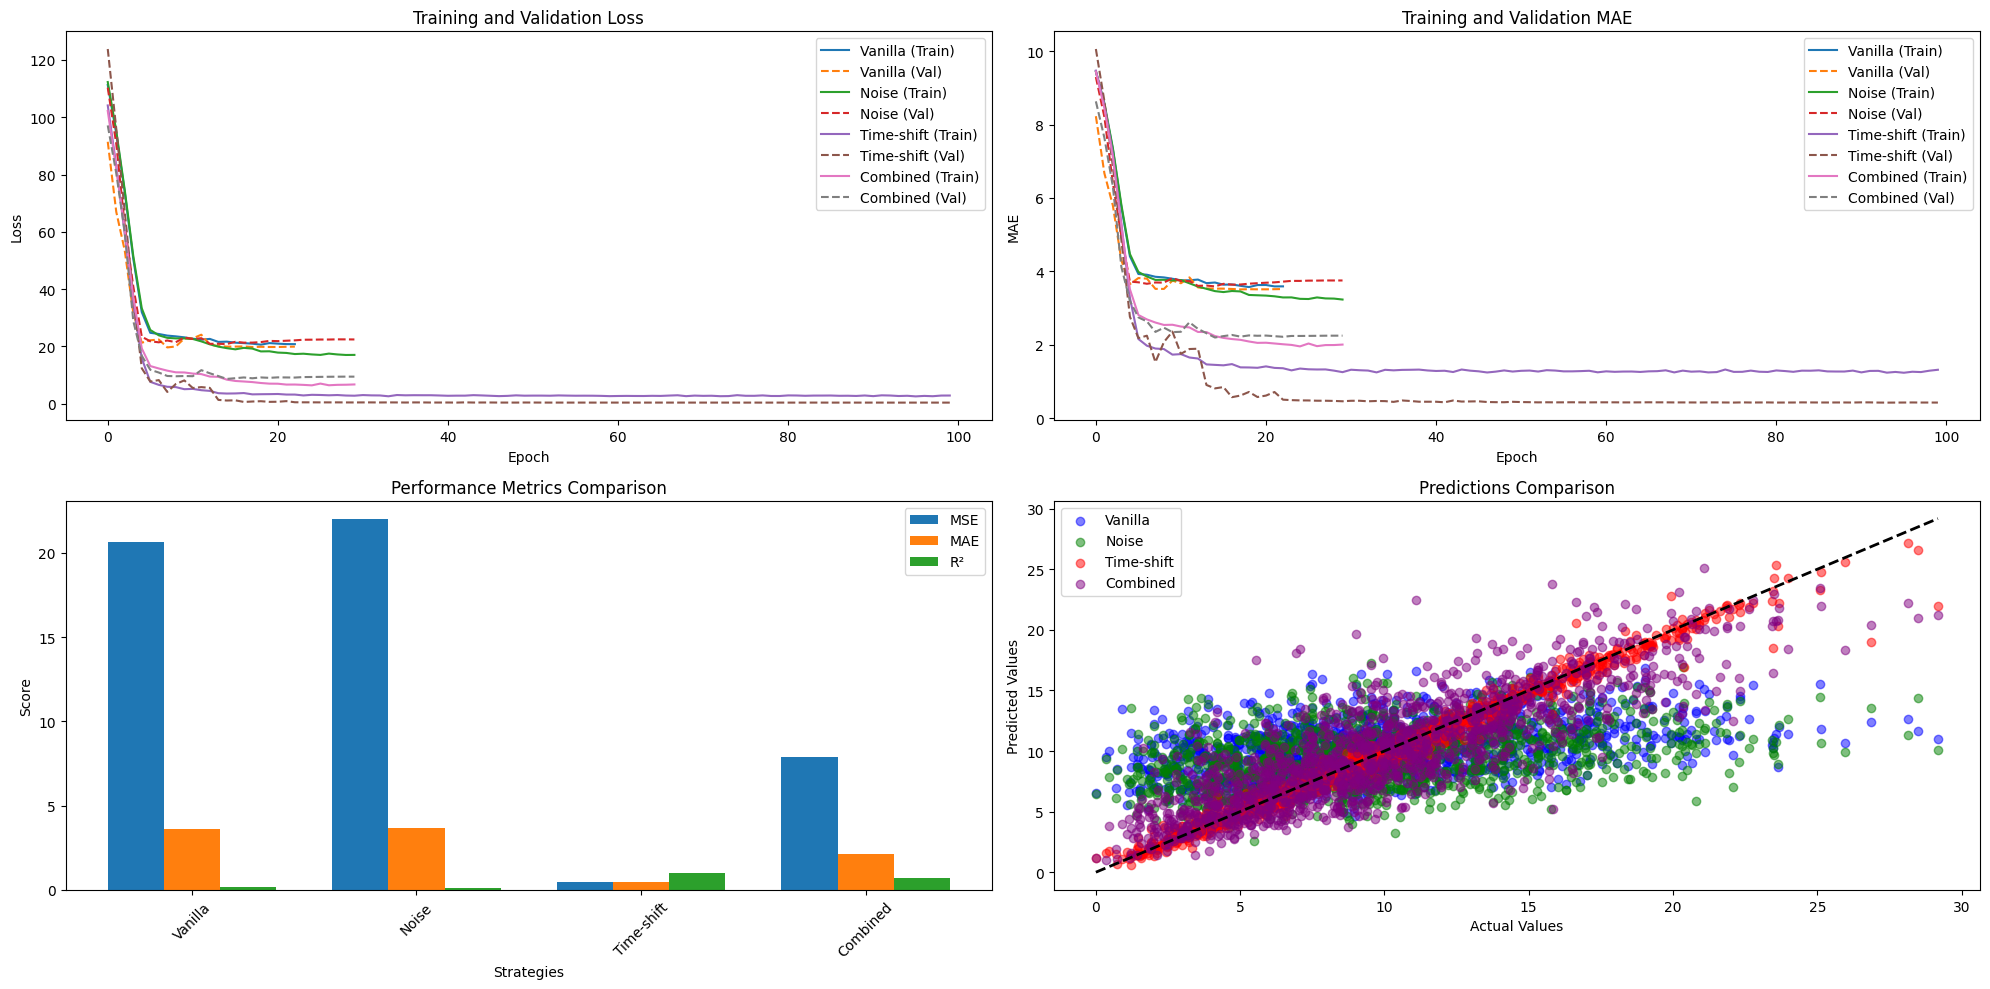

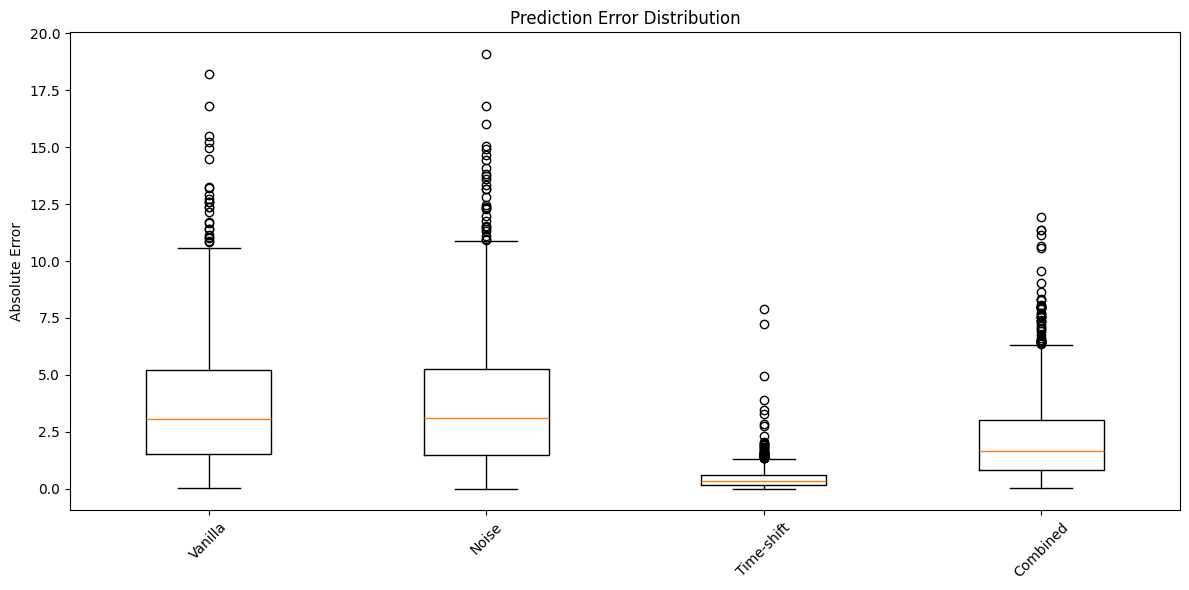


ShuffleNet Results Summary:
--------------------------------------------------

Strategy: Vanilla
MSE: 20.6672
MAE: 3.6385
R²: 0.1757

Strategy: Noise
MSE: 21.9878
MAE: 3.6887
R²: 0.1231

Strategy: Time-shift
MSE: 0.4666
MAE: 0.4586
R²: 0.9814

Strategy: Combined
MSE: 7.8810
MAE: 2.1361
R²: 0.6857

Improvement over Vanilla strategy:
--------------------------------------------------

Noise strategy:
MSE improvement: -6.39%
MAE improvement: -1.38%
R² improvement: -29.97%

Time-shift strategy:
MSE improvement: 97.74%
MAE improvement: 87.40%
R² improvement: 458.43%

Combined strategy:
MSE improvement: 61.87%
MAE improvement: 41.29%
R² improvement: 290.15%


In [ ]:
# 创建自定义层实现channel shuffle (1D版本)
class ChannelShuffle1D(Layer):
    def __init__(self, groups, **kwargs):
        super(ChannelShuffle1D, self).__init__(**kwargs)
        self.groups = groups

    def call(self, inputs):
        batch_size, length, channels = inputs.shape
        channels_per_group = channels // self.groups

        # Reshape and transpose to achieve channel shuffle
        x = tf.reshape(inputs, [-1, length, self.groups, channels_per_group])
        x = tf.transpose(x, [0, 1, 3, 2])
        x = tf.reshape(x, [-1, length, channels])
        return x

def shuffle_unit_1d(x, in_channels, out_channels, strides=1):
    shortcut = x

    if strides == 2:
        # 空间下采样路径
        x = tf.keras.layers.DepthwiseConv1D(kernel_size=3, strides=2, padding="same")(x)
        x = BatchNormalization()(x)
        x = Conv1D(out_channels, kernel_size=1, strides=1, padding="same")(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)
    else:
        # 主路径
        x = Conv1D(out_channels // 2, kernel_size=1, strides=1, padding="same")(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)

        x = tf.keras.layers.DepthwiseConv1D(kernel_size=3, strides=strides, padding="same")(x)
        x = BatchNormalization()(x)

        x = Conv1D(out_channels, kernel_size=1, strides=1, padding="same")(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)

    # 残差连接
    if strides == 2 or in_channels != out_channels:
        shortcut = Conv1D(out_channels, kernel_size=1, strides=strides, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # 添加残差连接
    x = tf.keras.layers.Add()([x, shortcut])

    # Channel shuffle
    x = ChannelShuffle1D(groups=2)(x)

    return x

def build_shufflenet_1d(input_shape, num_blocks=[2, 4, 2]):
    inputs = Input(shape=input_shape)

    # 初始特征提取
    x = Conv1D(24, kernel_size=3, strides=1, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # ShuffleNet stages
    out_channels = [24, 48, 96, 192]
    for i, blocks in enumerate(num_blocks):
        for j in range(blocks):
            strides = 2 if j == 0 and i > 0 else 1
            x = shuffle_unit_1d(x, out_channels[i], out_channels[i + 1], strides=strides)

    # 全局平均池化
    x = GlobalAveragePooling1D()(x)

    # 添加额外的全连接层
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # 输出层
    outputs = Dense(1, activation="linear")(x)

    # 创建模型
    model = Model(inputs, outputs)
    return model


def train_and_evaluate_shufflenet(x_train, x_test, y_train, y_test, strategy_name):
    # 确保输入数据形状正确
    if len(x_train.shape) == 2:
        x_train = np.expand_dims(x_train, axis=-1)
        x_test = np.expand_dims(x_test, axis=-1)

    input_shape = (x_train.shape[1], x_train.shape[2])

    # 构建模型
    model = build_shufflenet_1d(input_shape)

    # 添加回调函数
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )
    ]

    # 编译模型
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
        loss='mse',
        metrics=['mae']
    )

    # 训练模型
    history = model.fit(
        x_train,
        y_train,
        batch_size=64,
        epochs=10,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    # 预测
    y_pred = model.predict(x_test)

    # 计算评估指标
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'strategy': strategy_name,
        'history': history.history,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'y_pred': y_pred
    }

# 训练所有策略
strategies = {
    'Vanilla': (x_train_va, x_test_va,y_train_va,y_test_va),
    'Noise': (x_train_no, x_test_no,y_train_no,y_test_no),
    'Time-shift': (x_train_ti, x_test_ti,y_train_ti,y_test_ti),
    'Combined': (x_train_co, x_test_co,y_train_co,y_test_co)
}

# 存储结果
shufflenet_results = []

# 训练和评估每个策略
for strategy_name, (x_train, x_test,y_train,y_test) in strategies.items():
    print(f"Training ShuffleNet with {strategy_name} strategy...")
    result = train_and_evaluate_shufflenet(x_train, x_test, y_train, y_test, strategy_name)
    shufflenet_results.append(result)


plt.style.use('default')

# 1. 训练历史对比
plt.figure(figsize=(20, 10))

# 损失曲线对比
plt.subplot(2, 2, 1)
for result in shufflenet_results:
    plt.plot(result['history']['loss'],
             label=f"{result['strategy']} (Train)")
    plt.plot(result['history']['val_loss'],
             linestyle='--',
             label=f"{result['strategy']} (Val)")
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE曲线对比
plt.subplot(2, 2, 2)
for result in shufflenet_results:
    plt.plot(result['history']['mae'],
             label=f"{result['strategy']} (Train)")
    plt.plot(result['history']['val_mae'],
             linestyle='--',
             label=f"{result['strategy']} (Val)")
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

# 评估指标对比
plt.subplot(2, 2, 3)
metrics = ['mse', 'mae', 'r2']
values = {metric: [result[metric] for result in shufflenet_results] for metric in metrics}
strategies_names = [result['strategy'] for result in shufflenet_results]

x = np.arange(len(strategies_names))
width = 0.25

plt.bar(x - width, values['mse'], width, label='MSE')
plt.bar(x, values['mae'], width, label='MAE')
plt.bar(x + width, values['r2'], width, label='R²')

plt.xlabel('Strategies')
plt.ylabel('Score')
plt.title('Performance Metrics Comparison')
plt.xticks(x, strategies_names, rotation=45)
plt.legend()

# 预测对比
plt.subplot(2, 2, 4)
colors = ['blue', 'green', 'red', 'purple']
for i, result in enumerate(shufflenet_results):
    plt.scatter(y_test, result['y_pred'],
               alpha=0.5,
               color=colors[i],
               label=result['strategy'])
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predictions Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# 2. 预测误差分布对比
plt.figure(figsize=(12, 6))
error_data = []
labels = []
for result in shufflenet_results:
    errors = np.abs(y_test - result['y_pred'].flatten())
    error_data.append(errors)
    labels.extend([result['strategy']] * len(errors))

plt.boxplot(error_data, labels=strategies_names)
plt.title('Prediction Error Distribution')
plt.ylabel('Absolute Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 打印详细结果
print("\nShuffleNet Results Summary:")
print("-" * 50)
for result in shufflenet_results:
    print(f"\nStrategy: {result['strategy']}")
    print(f"MSE: {result['mse']:.4f}")
    print(f"MAE: {result['mae']:.4f}")
    print(f"R²: {result['r2']:.4f}")

# 3. 计算和显示改进百分比
baseline_metrics = next(r for r in shufflenet_results if r['strategy'] == 'Vanilla')
print("\nImprovement over Vanilla strategy:")
print("-" * 50)
for result in shufflenet_results:
    if result['strategy'] != 'Vanilla':
        mse_improvement = (baseline_metrics['mse'] - result['mse']) / baseline_metrics['mse'] * 100
        mae_improvement = (baseline_metrics['mae'] - result['mae']) / baseline_metrics['mae'] * 100
        r2_improvement = (result['r2'] - baseline_metrics['r2']) / baseline_metrics['r2'] * 100

        print(f"\n{result['strategy']} strategy:")
        print(f"MSE improvement: {mse_improvement:.2f}%")
        print(f"MAE improvement: {mae_improvement:.2f}%")
        print(f"R² improvement: {r2_improvement:.2f}%")

## Resnet

Training ResNet with Vanilla strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Training ResNet with Noise strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Training ResNet with Time-shift strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Training ResNet with Combined strategy...
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


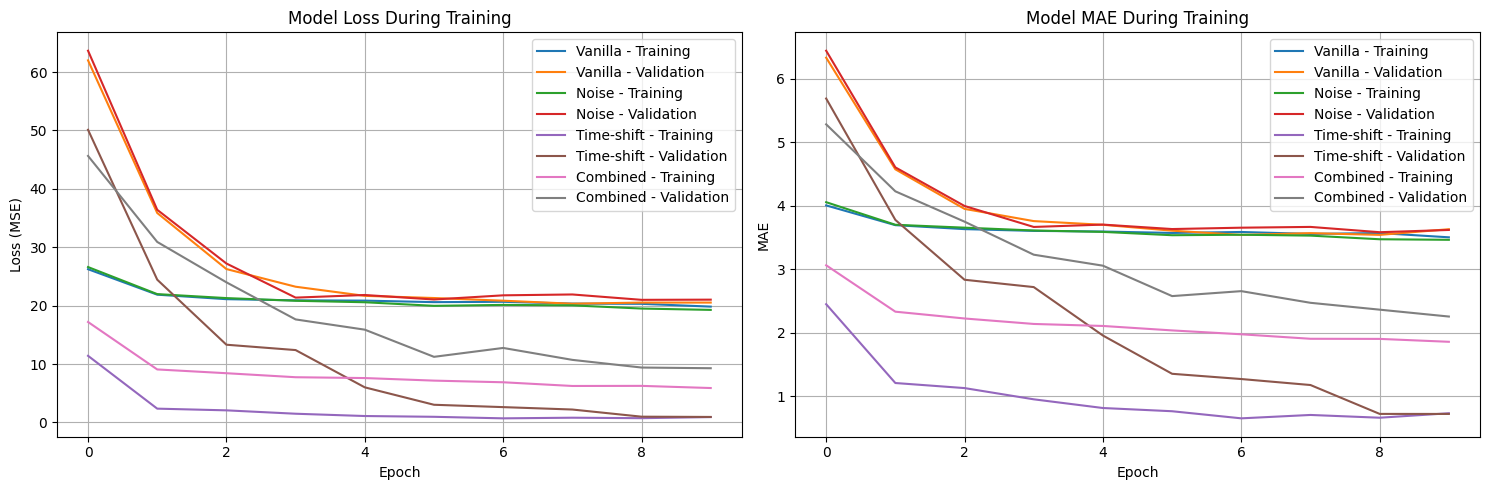

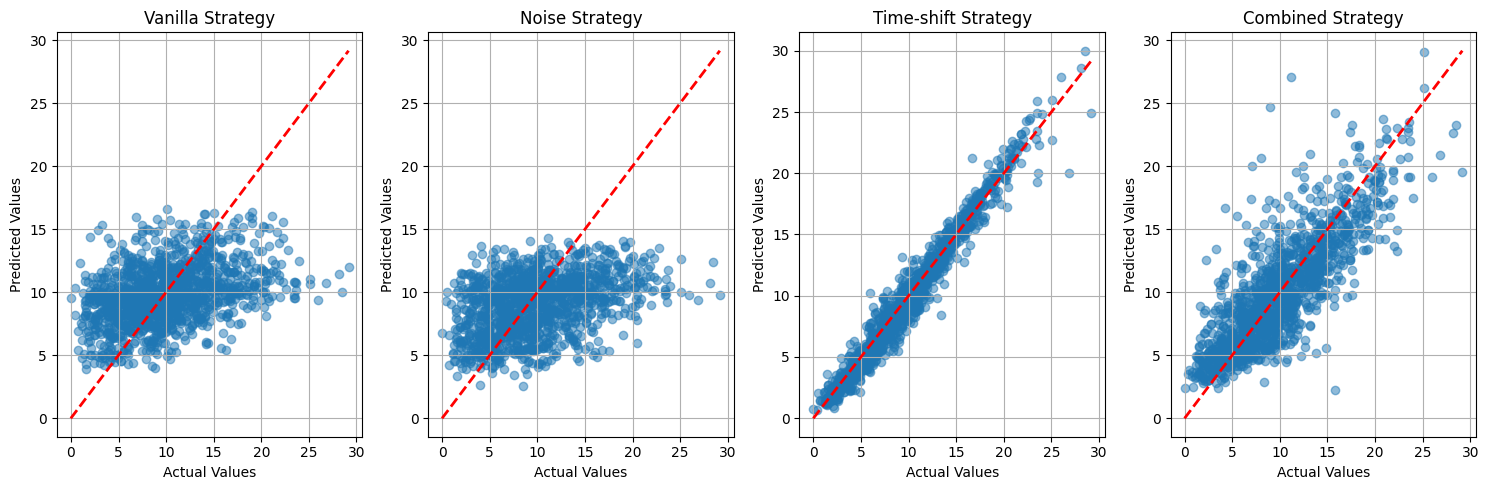

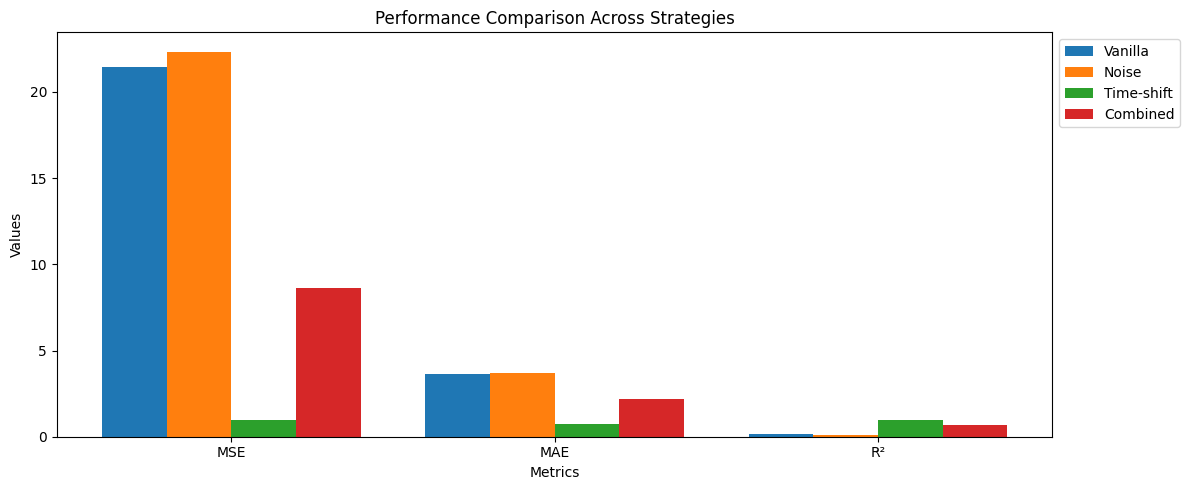


ShuffleNet Results Summary:
--------------------------------------------------


NameError: name 'shufflenet_results' is not defined

In [ ]:
def build_resnet_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, kernel_size=7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=3, strides=2, padding="same")(x)

    def residual_block(x, filters, strides=1):
        shortcut = x

        x = layers.Conv1D(filters, kernel_size=3, strides=strides, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv1D(filters, kernel_size=3, strides=1, padding="same")(x)
        x = layers.BatchNormalization()(x)

        if strides > 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, kernel_size=1, strides=strides, padding="same")(shortcut)
        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    for filters, blocks, strides in [(64, 3, 1), (128, 4, 2)]:
        for block in range(blocks):
            x = residual_block(x, filters, strides if block == 0 else 1)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1, activation="linear")(x)

    model = Model(inputs, outputs)
    return model


def train_and_evaluate_resnet(x_train, x_test, y_train, y_test, strategy_name):
    """训练和评估ResNet模型"""

    # 确保输入数据形状正确
    if len(x_train.shape) == 2:
        x_train = np.expand_dims(x_train, axis=-1)
        x_test = np.expand_dims(x_test, axis=-1)

    input_shape = (x_train.shape[1],1)

    # 构建模型
    model = build_resnet_model(input_shape)

    # 添加回调函数
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )
    ]

    # 编译模型
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    # 训练模型
    history = model.fit(
        x_train,
        y_train,
        batch_size=64,
        epochs=10,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    # 预测
    y_pred = model.predict(x_test)

    # 计算评估指标
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'strategy': strategy_name,
        'history': history.history,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'y_pred': y_pred
    }

# 训练所有策略
strategies = {
    'Vanilla': (x_train_va, x_test_va,y_train_va,y_test_va),
    'Noise': (x_train_no, x_test_no,y_train_no,y_test_no),
    'Time-shift': (x_train_ti, x_test_ti,y_train_ti,y_test_ti),
    'Combined': (x_train_co, x_test_co,y_train_co,y_test_co)
}

# 存储结果
resnet_results = []

# 训练和评估每个策略
for strategy_name, (x_train, x_test,y_train,y_test) in strategies.items():
    print(f"Training ResNet with {strategy_name} strategy...")
    result = train_and_evaluate_resnet(x_train, x_test, y_train, y_test, strategy_name)
    resnet_results.append(result)

plt.style.use('default')

# 1. 绘制损失曲线
plt.figure(figsize=(15, 5))

# 训练损失
plt.subplot(1, 2, 1)
for result in resnet_results:
    plt.plot(result['history']['loss'], label=f"{result['strategy']} - Training")
    plt.plot(result['history']['val_loss'], label=f"{result['strategy']} - Validation")
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# MAE指标
plt.subplot(1, 2, 2)
for result in resnet_results:
    plt.plot(result['history']['mae'], label=f"{result['strategy']} - Training")
    plt.plot(result['history']['val_mae'], label=f"{result['strategy']} - Validation")
plt.title('Model MAE During Training')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. 绘制预测vs实际值的散点图
plt.figure(figsize=(15, 5))
for i, result in enumerate(resnet_results, 1):
    plt.subplot(1, 4, i)
    plt.scatter(y_test, result['y_pred'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'{result["strategy"]} Strategy')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
plt.tight_layout()
plt.show()

# 3. 绘制性能指标对比柱状图
metrics = ['MSE', 'MAE', 'R²']
values = np.array([[r['mse'], r['mae'], r['r2']] for r in resnet_results])
strategies = [r['strategy'] for r in resnet_results]

plt.figure(figsize=(12, 5))
x = np.arange(len(metrics))
width = 0.2
multiplier = 0

for i, strategy in enumerate(strategies):
    offset = width * multiplier
    plt.bar(x + offset, values[i], width, label=strategy)
    multiplier += 1

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Performance Comparison Across Strategies')
plt.xticks(x + width * (len(strategies) - 1) / 2, metrics)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# # 4. 绘制改进百分比的热力图
# improvement_data = []
# metrics = ['MSE', 'MAE', 'R²']
# strategies = [r['strategy'] for r in resnet_results if r['strategy'] != 'Vanilla']

# for result in resnet_results:
#     if result['strategy'] != 'Vanilla':
#         mse_imp = (baseline_metrics['mse'] - result['mse']) / baseline_metrics['mse'] * 100
#         mae_imp = (baseline_metrics['mae'] - result['mae']) / baseline_metrics['mae'] * 100
#         r2_imp = (result['r2'] - baseline_metrics['r2']) / baseline_metrics['r2'] * 100
#         improvement_data.append([mse_imp, mae_imp, r2_imp])

# plt.figure(figsize=(10, 6))
# sns.heatmap(improvement_data,
#             annot=True,
#             fmt='.1f',
#             xticklabels=metrics,
#             yticklabels=strategies,
#             cmap='RdYlGn',
#             center=0)
# plt.title('Improvement Percentage Over Vanilla Strategy')
# plt.tight_layout()
# plt.show()




In [ ]:
# 打印详细结果
print("\nResNet Results Summary:")
print("-" * 50)
for result in resnet_results:
    print(f"\nStrategy: {result['strategy']}")
    print(f"MSE: {result['mse']:.4f}")
    print(f"MAE: {result['mae']:.4f}")
    print(f"R²: {result['r2']:.4f}")


ResNet Results Summary:
--------------------------------------------------

Strategy: Vanilla
MSE: 21.4161
MAE: 3.6391
R²: 0.1459

Strategy: Noise
MSE: 22.3354
MAE: 3.7033
R²: 0.1092

Strategy: Time-shift
MSE: 0.9914
MAE: 0.7323
R²: 0.9605

Strategy: Combined
MSE: 8.6063
MAE: 2.2062
R²: 0.6568
